# Radiogenomic Recoverability — Image-Identifiable Genomic Subspaces

This notebook implements the linear–Gaussian model of `main.tex` on a pair of
[`AnnData`](https://anndata.readthedocs.io/) objects:

- **genomics** — a patient × genomics matrix $\mathbf{G}\in\mathbb{R}^{n\times p}$
- **imaging** — a patient × imaging matrix $\mathbf{X}\in\mathbb{R}^{n\times d}$

Set the two `.h5ad` paths in the configuration cell. If they are absent, the
notebook falls back to a **synthetic dataset with known ground truth**, so every
estimate can be checked against the value it is supposed to recover.

The question is not *"does imaging predict gene $j$?"* but *"which low-dimensional
genomic subspaces are image-identifiable?"* — answered by the **recoverability
spectrum** $\{\rho_i^2\}$ and the genomic directions $\{a_i\}$ that achieve it.
All heavy lifting lives in the `rgit` package; the notebook just orchestrates and
visualizes.

## The model in brief

Genomics has a Gaussian prior and imaging is a noisy linear readout of it:

$$G \sim \mathcal{N}(0,\Sigma_G), \qquad X \mid G \sim \mathcal{N}(AG,\ \sigma^2 I_d).$$

Every quantity below is then closed-form (see `main.tex` for derivations):

| quantity | formula | meaning |
|---|---|---|
| Bayes-optimal predictor | $\hat g(x)=\Sigma_{GX}\Sigma_X^{-1}x$ | best possible $E[g\mid x]$ |
| posterior covariance | $\Sigma_{G\mid X}=\Sigma_G-\Sigma_{GX}\Sigma_X^{-1}\Sigma_{XG}$ | hard floor on residual uncertainty |
| recoverability of $a_i$ | $R_i=\rho_i^2$ | $1-$ fraction of variance surviving imaging |
| mutual information | $I(G;X)=-\tfrac12\sum_i\log(1-\rho_i^2)$ | total information budget |

The recoverability directions solve a generalized eigenproblem that **coincides
with canonical correlation analysis** between $\mathbf{G}$ and $\mathbf{X}$, so we
only ever estimate the three second moments $\Sigma_G,\Sigma_X,\Sigma_{GX}$ —
never $A$ or $\sigma^2$ individually.

## 1 · Configuration and imports

In [ ]:
import os
import sys
from pathlib import Path
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import anndata as ad
import scipy.sparse as sp
import scipy.stats as _st
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import roc_auc_score
from sklearn.preprocessing import StandardScaler as _SS
import scanpy as sc

# --- make the rgit package importable whether or not it is pip-installed ---
REPO_ROOT = Path.cwd().parent.parent if Path.cwd().name == "out" else Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(REPO_ROOT) not in sys.path:
    sys.path.insert(0, str(REPO_ROOT))

import rgit

genomics_preset_keys = {
    "tcga_gene_expression": (REPO_ROOT / "data" / "tcga_kirc" / "genomics" / "gene_expression.h5ad", "expression"),
    "tcga_mutated_genes": (REPO_ROOT / "data" / "tcga_kirc" / "genomics" / "mutated_genes.h5ad", "variant"),
    "tcga_mutated_pathways": (REPO_ROOT / "data" / "tcga_kirc" / "genomics" / "mutated_pathways.h5ad", "variant"),
    "nsclc_gene_expression": (REPO_ROOT / "data" / "nsclc" / "genomics" / "gene_expression.h5ad", "expression"),
    "adni_gene_expression": (REPO_ROOT / "data" / "adni" / "genomics" / "gene_expression.h5ad", "expression"),
    "synthetic_gene_expression": (REPO_ROOT / "data" / "synthetic" / "genomics" / "gene_expression_synthetic.h5ad", "expression"),
    "synthetic_mutated_genes": (REPO_ROOT / "data" / "synthetic" / "genomics" / "mutated_genes_synthetic.h5ad", "variant"),
}

imaging_preset_keys = {
    "tcga_tumor_radiomics": (REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "tumor_radiomics.h5ad"),
    "tcga_organ_radiomics": (REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "organ_radiomics.h5ad"),
    "tcga_tumor_radimagenet": (REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "tumor_radimagenet.h5ad"),
    "tcga_organ_radimagenet": (REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "organ_radimagenet.h5ad"),
    "tcga_whole_radimagenet": (REPO_ROOT / "data" / "tcga_kirc" / "imaging" / "whole_radimagenet.h5ad"),
    "nsclc_organ_radiomics": (REPO_ROOT / "data" / "nsclc" / "imaging" / "organ_radiomics_subset.h5ad"),
    "adni_fastsurfer": (REPO_ROOT / "data" / "adni" / "imaging" / "fastsurfer.h5ad"),
    "synthetic_imaging": (REPO_ROOT / "data" / "synthetic" / "imaging" / "imaging_synthetic.h5ad"),
}

# presets can be overridden by env vars so the notebook runs headless per cohort
genomics_preset = os.environ.get("RGIT_GEN_PRESET", "synthetic_gene_expression")
imaging_preset  = os.environ.get("RGIT_IMG_PRESET", "synthetic_imaging")
print(f"presets: genomics={genomics_preset}  imaging={imaging_preset}")

## Change these with custom paths if desired

In [ ]:
# --- paths to the two AnnData objects -------------------------------------
GENOMICS_H5AD = REPO_ROOT / "data" / "synthetic" / "genomics" / "gene_expression.h5ad"
IMAGING_H5AD  = REPO_ROOT / "data" / "synthetic" / "imaging" / "tumor_radimagenet.h5ad"
GENOMICS_DATA_TYPE = "variant"  # variant or expression

In [ ]:
if genomics_preset is not None:
    GENOMICS_H5AD, GENOMICS_DATA_TYPE = genomics_preset_keys[genomics_preset]
if imaging_preset is not None:
    IMAGING_H5AD = imaging_preset_keys[imaging_preset]

USE_SYNTHETIC = not (GENOMICS_H5AD.exists() and IMAGING_H5AD.exists())

# --- gene expression filtering -------------------------------------------
EXPRESSION_LAYER        = "unstranded"  # which layer to use as X
MIN_EXPRESSED_PATIENTS  = 3              # minimum patients expressing a gene
DO_CPM_NORMALIZATION    = True                            # whether to convert raw counts to counts-per-million
DO_LOG1P                = True                            # whether to log-transform the expression data after filtering
DO_HVG_SELECTION        = True                            # whether to select highly variable genes after filtering
USE_COPULA              = True                            # Gaussian-copula (rank->inverse-normal) marginal transform on both modalities
NUM_BINS                = None               # if >0, binarize expression into this many quantiles

# --- analysis settings ----------------------------------------------------
SEED                    = 0
N_COMPONENTS_MAX        = 12     # upper bound on canonical directions reported
SAMPLES_PER_DIM         = 5      # target ratio n / dim(modality) after reduction
MIN_WORKING_DIM         = 4      # never reduce below this many components
N_FOLDS                 = 5      # cross-validation folds
N_PERM                  = 200    # permutations for the significance test

# Heuristic: CCA-style estimators trivially saturate (rho_i = 1) once the working
# dimension of either modality approaches n; even with shrinkage the in-sample
# spectrum is heavily biased upward when dim is a sizeable fraction of n. We
# therefore cap each modality's working dimension at ~n / SAMPLES_PER_DIM,
# applying PCA on whichever side exceeds that budget.

# --- figure & statistics export ------------------------------------------
SAVE_FIGURES = True
FIGURES_DIR  = REPO_ROOT / "notebooks" / "figures" / GENOMICS_H5AD.parent.parent.stem / GENOMICS_H5AD.stem / IMAGING_H5AD.stem
STATS_PATH   = FIGURES_DIR / "stats.json"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# Manuscript-side statistics accumulate here and are dumped to STATS_PATH at the end.
stats: dict = {
    "genomics_h5ad": str(GENOMICS_H5AD),
    "imaging_h5ad":  str(IMAGING_H5AD),
    "genomics_stem": GENOMICS_H5AD.stem,
    "imaging_stem":  IMAGING_H5AD.stem,
}

def savefig(name: str, fig=None, dpi: int = 150):
    """Save the current (or supplied) matplotlib figure to FIGURES_DIR as PDF + PNG."""
    if not SAVE_FIGURES:
        return
    f = fig if fig is not None else plt.gcf()
    for ext in ("pdf", ):  # ("pdf", "png")
        f.savefig(FIGURES_DIR / f"{name}.{ext}", dpi=dpi, bbox_inches="tight")
    print(f"saved figure: {(FIGURES_DIR / name).relative_to(REPO_ROOT)}.{{pdf,png}}")

plt.rcParams.update({"figure.dpi": 110, "axes.grid": True, "grid.alpha": 0.3})
rng = np.random.default_rng(SEED)
print(f"repo root         : {REPO_ROOT}")
print(f"using synthetic   : {USE_SYNTHETIC}")
print(f"figures dir       : {FIGURES_DIR.relative_to(REPO_ROOT)}")


# --- demographic deconfounding (cohorts with a demographics table) -------
# DECONFOUND=True makes the *main* analysis run on features with the listed
# confounders linearly regressed out of both modalities; default False keeps
# the raw analysis. The with-vs-without comparison cell always shows both.
demographics_preset_keys = {
    "adni_gene_expression": REPO_ROOT / "data" / "adni" / "demographics.csv",
}
DEMOGRAPHICS_CSV = demographics_preset_keys.get(genomics_preset, None)
CONFOUNDER_COLS  = ["age", "sex", "education"]
DECONFOUND       = os.environ.get("RGIT_DECONFOUND", "0") == "1"

# --- optional downsampling of the working cohort ------------------------
# If set, the *main* analysis runs on a random subsample of this many patients
# (None -> use all). The dedicated downsample sweep below always scans a range
# of fractions regardless of this value.
DOWNSAMPLE_N     = os.environ.get("RGIT_DOWNSAMPLE_N")
DOWNSAMPLE_N     = int(DOWNSAMPLE_N) if DOWNSAMPLE_N else None
DOWNSAMPLE_SEED  = 0
DOWNSAMPLE_FRACS = [0.1, 0.2, 0.35, 0.5, 0.7, 0.85, 1.0]


repo root         : /home/jrich/Desktop/rgit-private
using synthetic   : False
figures dir       : notebooks/figures/adni/gene_expression/fastsurfer


In [4]:
if GENOMICS_DATA_TYPE not in ("variant", "expression"):
    raise ValueError(f"unrecognized GENOMICS_DATA_TYPE: {GENOMICS_DATA_TYPE!r} "
                     "(expected 'variant' or 'expression')")
if GENOMICS_DATA_TYPE == "variant":
    DO_CPM_NORMALIZATION = False
    DO_LOG1P             = False
    DO_HVG_SELECTION     = False

# ADNI gene expression is Affymetrix microarray: values are already normalized,
# log-scale intensities (range ~1-13), not RNA-seq counts. CPM library-size
# normalization and a second log1p are both inappropriate here, so we disable
# them and rely on HVG selection + the Gaussian copula transform.
if genomics_preset == "adni_gene_expression":
    DO_CPM_NORMALIZATION = False
    DO_LOG1P             = False
    DO_HVG_SELECTION     = True


## 2 · Load the data

`load_data()` reads the two `.h5ad` files when they exist. Otherwise it draws a
synthetic dataset from the probabilistic-CCA generative model
($Z\in\mathbb{R}^k$ shared latent, modality-private anisotropic noise) and wraps
it in `AnnData` objects with the same interface — including a deliberately
shuffled patient order on the imaging side, so the alignment step is exercised.
When synthetic, `truth` carries the generative parameters for later validation.

In [5]:
def load_data_real():
    gen = ad.read_h5ad(GENOMICS_H5AD)
    img = ad.read_h5ad(IMAGING_H5AD)

    # keep only patients with both genomics and imaging
    common_patients = gen.obs_names.intersection(img.obs_names)

    gen = gen[common_patients].copy()
    img = img[common_patients].copy()

    # select expression layer
    if EXPRESSION_LAYER in gen.layers:
        X = gen.layers[EXPRESSION_LAYER]
    else:
        X = gen.X

    # convert sparse -> dense once
    if sp.issparse(X):
        X = X.toarray()
    else:
        X = np.asarray(X)

    # ensure numeric dtype; some cohorts (NSCLC) carry NaNs -> treat as unmeasured
    X = X.astype(np.float32)
    X = np.nan_to_num(X, nan=0.0)

    # # commented out because I should not bin before PCA
    # # optional quantile binning
    # if NUM_BINS > 0:
    #     gen.layers["non_binned"] = X.copy()  # preserve raw expression before binning
    #     X_binned = np.zeros_like(X, dtype=np.int8)

    #     for i in range(X.shape[1]):
    #         col = X[:, i]

    #         # handle constant columns
    #         if np.all(col == col[0]):
    #             X_binned[:, i] = 0
    #             continue

    #         try:
    #             binned = pd.qcut(
    #                 col,
    #                 q=NUM_BINS,
    #                 labels=False,
    #                 duplicates="drop",
    #             )

    #             # qcut may return NaNs
    #             X_binned[:, i] = np.nan_to_num(
    #                 np.asarray(binned),
    #                 nan=0,
    #             ).astype(np.int8)

    #         except ValueError:
    #             # fallback for pathological columns
    #             X_binned[:, i] = 0

    #     X = X_binned

    # assign processed matrix back
    gen.X = X

    # filter genes expressed in >= MIN_EXPRESSED_PATIENTS
    if MIN_EXPRESSED_PATIENTS > 0:
        expressed = (X > 0).sum(axis=0)
        expressed = np.asarray(expressed).ravel()
        keep = expressed >= MIN_EXPRESSED_PATIENTS
        gen = gen[:, keep].copy()
    
    if DO_CPM_NORMALIZATION:
        sc.pp.normalize_total(gen, target_sum=1e6, inplace=True)
    
    if DO_LOG1P:
        # print(gen.X.min())
        # print(gen.X.max())
        # print(np.percentile(gen.X, [50, 90, 99]))
        gen.X = np.log1p(gen.X)
    
    if DO_HVG_SELECTION:
        sc.pp.highly_variable_genes(gen, n_top_genes=2000, subset=True)

    print(f"loaded genomics {gen.shape} and imaging {img.shape} from disk")

    return gen, img, None

def load_data():
    '''Return (genomics_adata, imaging_adata, truth_or_None).'''
    if not USE_SYNTHETIC:
        return load_data_real()

    # ---- synthetic fallback with known ground truth ----
    G, X, truth = rgit.make_synthetic_radiogenomics(
        n=800, p=80, d=40, k=6, random_state=SEED,
        genomics_type="gaussian" if GENOMICS_DATA_TYPE == "expression" else "bernoulli",
    )
    patients = np.array([f"P{i:04d}" for i in range(G.shape[0])])
    genes    = [f"GENE{i:04d}" for i in range(G.shape[1])]
    feats    = [f"radiomic_{i:03d}" for i in range(X.shape[1])]

    gen = ad.AnnData(
        X=G, obs=pd.DataFrame(index=patients),
        var=pd.DataFrame(index=genes),
    )
    # shuffle imaging patient order to make alignment non-trivial
    order = rng.permutation(G.shape[0])
    img = ad.AnnData(
        X=X[order], obs=pd.DataFrame(index=patients[order]),
        var=pd.DataFrame(index=feats),
    )
    print(f"synthetic genomics {gen.shape} and imaging {img.shape} "
          f"(true shared rank k={truth['k']})")

    GENOMICS_H5AD.parent.mkdir(parents=True, exist_ok=True)
    IMAGING_H5AD.parent.mkdir(parents=True, exist_ok=True)

    gen.write_h5ad(str(GENOMICS_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    img.write_h5ad(str(IMAGING_H5AD).replace(".h5ad", "_synthetic.h5ad"))
    
    return gen, img, truth


genomics_adata, imaging_adata, truth = load_data()

loaded genomics (702, 2000) and imaging (702, 1022) from disk


In [6]:
# if gene_name in genomics_adata.var.columns, then pop out index and set it to gene_name
if "gene_name" in genomics_adata.var.columns:
    genomics_adata.var.reset_index(inplace=True)
    genomics_adata.var_names = genomics_adata.var["gene_name"].astype(str)
    genomics_adata.var.drop(columns=["gene_name"], inplace=True)

In [7]:
# print the 10 features in gen adata object with the highest total counts (ie sum across all rows)
genes_mutation_counts = genomics_adata.X.sum(axis=0)
genes_mutation_counts = np.asarray(genes_mutation_counts).flatten()
genes_mutation_counts = pd.Series(genes_mutation_counts, index=genomics_adata.var_names)
genes_mutation_counts = genes_mutation_counts.sort_values(ascending=False)
print(genes_mutation_counts.head(10))

gene_symbol
HBB                                   9019.815430
ENSG00000211592 || ENSG00000231486    8358.235352
GYPC                                  8207.010742
SLC25A39                              8152.503906
HBG1                                  8064.129883
HBG2                                  7990.385254
RPL17-C18ORF32 || RPL17               7912.945801
HBG1 || HBG2                          7885.157227
PI3                                   7870.596191
ALAS2                                 7866.702148
dtype: float32


## 3 · Align patients and preprocess

Steps:

1. **Align** on the intersection of `obs_names` so both matrices are
   patient-aligned, row for row.
2. **Standardize** each feature (z-score) within each modality.
3. **Optionally PCA-reduce genomics** when $p$ is large — the manuscript's rank
   limit (Prop. 6) says imaging can only expose a low-dimensional projection of
   genomics, so little is lost provided the retained dimension exceeds the
   recoverable rank. We keep the `PCA` object to back-project genomic directions
   to gene space for interpretation.

In [8]:
# 1 · align on shared patients --------------------------------------------
shared = genomics_adata.obs_names.intersection(imaging_adata.obs_names)
shared = pd.Index(sorted(shared))
if DOWNSAMPLE_N is not None and DOWNSAMPLE_N < len(shared):
    _ds_rng = np.random.default_rng(DOWNSAMPLE_SEED)
    shared = pd.Index(sorted(_ds_rng.choice(np.asarray(shared), size=DOWNSAMPLE_N, replace=False)))
    print(f"DOWNSAMPLE_N={DOWNSAMPLE_N}: main analysis restricted to {len(shared)} patients")
genomics_adata = genomics_adata[shared].copy()
imaging_adata  = imaging_adata[shared].copy()
assert (genomics_adata.obs_names == imaging_adata.obs_names).all()
n_samples = len(shared)
print(f"{n_samples} patients shared between modalities")

# 2 · standardize each modality -------------------------------------------
G_raw = rgit.to_dense(genomics_adata.X)
X_raw = rgit.to_dense(imaging_adata.X)

# Gaussian-copula Bernoulli transform for binary mutation matrices.
# Under the multivariate-probit model  G_j = 1{Z_j > tau_j},  Z ~ N(0, Sigma_Z)
# with unit diagonal and  tau_j = Phi^{-1}(1 - p_j),  the conditional mean of
# the latent coordinate given the observed call is the truncated-normal mean
#       E[Z_j | G_ij = 1] = +phi(tau_j) / p_j
#       E[Z_j | G_ij = 0] = -phi(tau_j) / (1 - p_j).
# Replacing the binary column by these two values gives a continuous surrogate
# whose covariance is the first-order tetrachoric estimate of Sigma_Z.  The rest
# of the pipeline (regularized CCA, MI, permutation, sweep) is unchanged.
# See manuscript Section: 'A Bernoulli extension for mutation data via a
# Gaussian copula'.
G_bin_global = None
if GENOMICS_DATA_TYPE == "variant":
    G_bin_global = (G_raw > 0).astype(np.int8)
    p_hat = G_bin_global.mean(axis=0).astype(float)
    # clip so tau is finite for genes mutated in 0 or n patients
    eps   = 0.5 / max(n_samples, 2)
    p_hat = np.clip(p_hat, eps, 1.0 - eps)
    tau     = _st.norm.ppf(1.0 - p_hat)
    phi_tau = _st.norm.pdf(tau)
    z_pos =  phi_tau / p_hat
    z_neg = -phi_tau / (1.0 - p_hat)
    G_raw = np.where(G_bin_global == 1, z_pos[None, :], z_neg[None, :]).astype(float)
    # per-gene binarization entropy gap, in nats: H(Z_j) - H(G_j).
    h_z = 0.5 * np.log(2 * np.pi * np.e)
    h_g = -(p_hat * np.log(p_hat) + (1 - p_hat) * np.log(1 - p_hat))
    bin_gap = h_z - h_g
    stats["bernoulli_copula"] = {
        "n_genes":           int(G_raw.shape[1]),
        "mean_mut_freq":     float(p_hat.mean()),
        "median_mut_freq":   float(np.median(p_hat)),
        "mean_bin_gap_nats": float(bin_gap.mean()),
    }
    # expose per-gene quantities for downstream cells
    variant_pergene = {"p_hat": p_hat, "tau": tau, "bin_gap": bin_gap}
    print(f"variant mode: latent-Gaussian transform applied to {G_raw.shape[1]} genes "
          f"(median mut freq {np.median(p_hat):.3f}, mean H(Z)-H(G) = "
          f"{bin_gap.mean():.2f} nats/gene)")
else:
    variant_pergene = None

# stash pre-copula marginals so the upfront normality diagnostics can
# report how far the RAW data were from Gaussian (justifying the copula).
X_premarg = X_raw.copy()
G_premarg = G_raw.copy()

# Gaussian-copula marginal transform: map every feature to an exact normal
# marginal so the linear-Gaussian fit keys on dependence, not heavy tails.
if USE_COPULA:
    X_raw = rgit.gaussian_rank_transform(X_raw)
    if GENOMICS_DATA_TYPE == 'expression':
        G_raw = rgit.gaussian_rank_transform(G_raw)
    print('applied Gaussian-copula marginal transform (USE_COPULA=True)')

G_std = StandardScaler().fit_transform(G_raw)
X_std = StandardScaler().fit_transform(X_raw)

# 3 · adaptive dimension reduction ----------------------------------------
# Target working dim per modality: n / SAMPLES_PER_DIM, but no fewer than
# MIN_WORKING_DIM and no more than the modality's native dimension or n-1.
def _reduce(M, name):
    p_native = M.shape[1]
    budget   = max(MIN_WORKING_DIM, n_samples // SAMPLES_PER_DIM)
    target   = min(p_native, n_samples - 1, budget)
    if target < p_native:
        pca = PCA(n_components=target, random_state=SEED).fit(M)
        return pca.transform(M), pca, f"{target} {name} PCs"
    return M, None, f"standardized {name} features"

G_model, pca_g, gen_space = _reduce(G_std, "genomic")
X_model, pca_x, img_space = _reduce(X_std, "imaging")

# cap N_COMPONENTS at the actual working rank we can support
N_COMPONENTS = max(1, min(N_COMPONENTS_MAX, G_model.shape[1], X_model.shape[1],
                          n_samples - 1))

gene_names = np.asarray(genomics_adata.var_names)
feat_names = np.asarray(imaging_adata.var_names)

def to_gene_loadings(dirs):
    '''Map directions in the modeling space back to (standardized) gene space.'''
    return pca_g.components_.T @ dirs if pca_g is not None else dirs

def to_feature_loadings(dirs):
    '''Map directions in the modeling space back to (standardized) imaging-feature space.'''
    return pca_x.components_.T @ dirs if pca_x is not None else dirs

# regime warning ---------------------------------------------------------
total_dim = G_model.shape[1] + X_model.shape[1]
if total_dim >= n_samples:
    print("WARNING: dim(G) + dim(X) >= n — in-sample CCA will saturate at "
          "rho_i = 1 by geometry alone. Trust the cross-validated spectrum "
          "and permutation test, not the in-sample numbers below.")
elif total_dim > n_samples // 2:
    print("NOTE: dim(G) + dim(X) > n/2 — in-sample canonical correlations are "
          "noticeably biased upward; rely on cross-validation for honest values.")

print(f"genomics modeled in : {gen_space}  -> G {G_model.shape}")
print(f"imaging  modeled in : {img_space}  -> X {X_model.shape}")
print(f"N_COMPONENTS        : {N_COMPONENTS} (capped by working dims and n-1)")

# record cohort dims for the manuscript
stats.update({
    "n_samples":      int(n_samples),
    "p_native_genes": int(G_raw.shape[1]),
    "d_native_feats": int(X_raw.shape[1]),
    "dim_g_model":    int(G_model.shape[1]),
    "dim_x_model":    int(X_model.shape[1]),
    "n_components":   int(N_COMPONENTS),
})

702 patients shared between modalities


applied Gaussian-copula marginal transform (USE_COPULA=True)


genomics modeled in : 140 genomic PCs  -> G (702, 140)
imaging  modeled in : 140 imaging PCs  -> X (702, 140)
N_COMPONENTS        : 12 (capped by working dims and n-1)


## 3b · Demographic confounders

Load a per-patient confounder design matrix (age, sex, education) where a
demographics table is available, and optionally residualize both modalities.

In [9]:
# --- demographic confounders: build a design matrix aligned to `shared` ----
# For cohorts with a demographics table (ADNI) we can regress age, sex and
# education out of *both* modalities, so the recoverability that survives is not
# a trivial age/sex-mediated association. We keep the raw modeling matrices
# (G_model_raw, X_model_raw) alongside; DECONFOUND controls whether the *main*
# analysis below uses the residualized features. All 702 ADNI subjects carry
# demographics, but we mean-impute any missing value rather than drop rows so
# every downstream cell stays row-aligned with the genomics matrix.
def load_confounders(patient_ids):
    """Return (DataFrame indexed by patient_id with CONFOUNDER_COLS, used_cols)."""
    if DEMOGRAPHICS_CSV is None or not Path(DEMOGRAPHICS_CSV).exists():
        return None, []
    demo = pd.read_csv(DEMOGRAPHICS_CSV, low_memory=False).drop_duplicates("PTID").set_index("PTID")
    yob = pd.to_datetime(demo["PTDOBYY"], errors="coerce").dt.year
    yob = yob.fillna(pd.to_numeric(demo["PTDOBYY"], errors="coerce"))
    rows = {}
    for pid in patient_ids:
        if pid not in demo.index:
            continue
        try:
            ycoll = float(str(genomics_adata.obs.loc[pid, "YearofCollection"]))
        except Exception:
            ycoll = 2011.0
        rows[pid] = {
            "age":       ycoll - float(yob.get(pid, np.nan)),
            "sex":       float(demo.loc[pid, "PTGENDER"]),     # 1=male, 2=female
            "education": pd.to_numeric(demo.loc[pid, "PTEDUCAT"], errors="coerce"),
        }
    C = pd.DataFrame.from_dict(rows, orient="index").replace({-4: np.nan})
    return C[CONFOUNDER_COLS], CONFOUNDER_COLS

def residualize(M, C):
    """Residuals of the columns of M after least-squares regression on [1, z(C)]."""
    D = np.column_stack([np.ones(len(C)), StandardScaler().fit_transform(C)])
    beta, *_ = np.linalg.lstsq(D, M, rcond=None)
    return M - D @ beta

_C_df, conf_cols = load_confounders(list(shared))
if _C_df is not None:
    C_full = _C_df.reindex(shared)
    C_full = C_full.fillna(C_full.mean()).values.astype(float)
    n_with = int(_C_df.dropna(how="any").shape[0])
    print(f"confounders {conf_cols}: present for {n_with}/{len(shared)} patients (missing mean-imputed)")
    stats["confounders"] = {"cols": conf_cols, "n_with_confounders": n_with, "n_total": int(len(shared))}
else:
    C_full = None
    print("no demographic confounders available for this cohort")

# keep raw copies; optionally replace the working matrices with residualized ones
G_model_raw, X_model_raw = G_model.copy(), X_model.copy()
if DECONFOUND and C_full is not None:
    G_model = residualize(G_model, C_full)
    X_model = residualize(X_model, C_full)
    print(f"DECONFOUND=True: main analysis uses features residualized on {conf_cols}")
elif DECONFOUND:
    print("DECONFOUND=True requested but no confounders available; using raw features")


confounders ['age', 'sex', 'education']: present for 702/702 patients (missing mean-imputed)



MVN diagnostic — imaging — 140 imaging PCs (raw p=1022 >= n=702, PCA proxy)  (n=702, p=140)
  Mardia skew ratio  b₁ₚ / [p(p+2)(p+4)] = +0.0017   (≈ 0 if MVN)
  Mardia kurt ratio  b₂ₚ / [p(p+2)]      = +1.0403   (≈ 1 if MVN)
  tail share beyond χ²_{p, .99}        = 6.268%    (≈ 1.0% if MVN)

MVN diagnostic — genomics — 140 genomic PCs (raw p=2000 >= n=702, PCA proxy)  (n=702, p=140)
  Mardia skew ratio  b₁ₚ / [p(p+2)(p+4)] = +0.0018   (≈ 0 if MVN)
  Mardia kurt ratio  b₂ₚ / [p(p+2)]      = +1.0823   (≈ 1 if MVN)
  tail share beyond χ²_{p, .99}        = 13.390%    (≈ 1.0% if MVN)


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/mvn_diagnostic.{pdf,png}


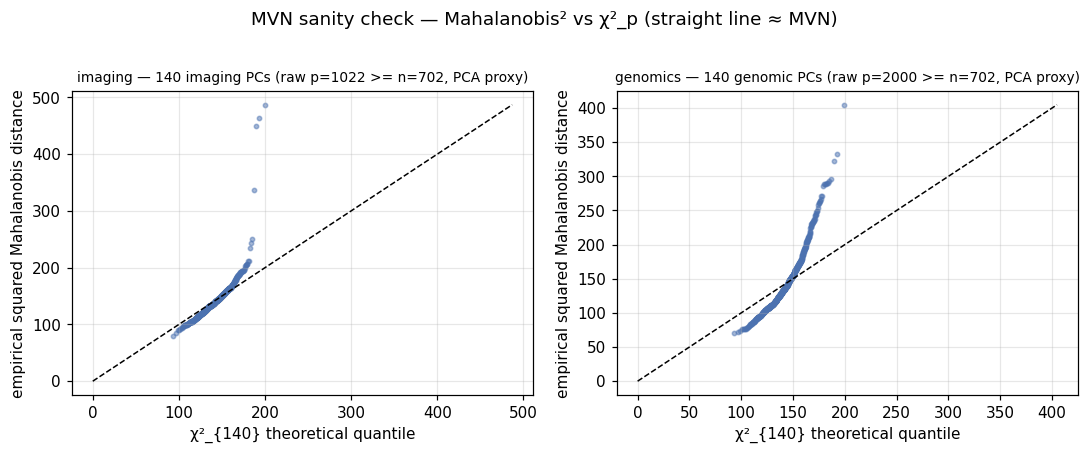

In [10]:
def _mvn_diagnostic(M, name="", ax=None):
    """
    Quick visual MVN check via Mahalanobis-distance QQ plot vs χ²_p quantiles.

    Under MVN, squared Mahalanobis distances d²_i = (x_i - μ̂)' Σ̂⁻¹ (x_i - μ̂)
    are approximately χ²_p distributed. The QQ plot vs χ²_p quantiles should lie
    on y = x. Systematic departures (heavy tails, skew, bimodality) show up as
    curvature; finite-sample noise shows up as scatter near the line.

    Also reports Mardia skewness/kurtosis as *standardized effect sizes*:
      skew_ratio = b₁ₚ / [p(p+2)(p+4)]   (≈ 0 under MVN)
      kurt_ratio = b₂ₚ / [p(p+2)]        (≈ 1 under MVN)
    These are scale-free indicators that don't suffer the over-power problem of
    the asymptotic Mardia p-values at large n.

    Requires n > p so Σ̂ is invertible.
    """
    n, p = M.shape
    if n <= p:
        print(f"\nMVN diagnostic — {name}: skipped (n={n} <= p={p}, Σ̂ singular).")
        return None

    Mc = M - M.mean(axis=0)
    S = (Mc.T @ Mc) / n
    S_inv = np.linalg.pinv(S)
    G = Mc @ S_inv @ Mc.T
    d2 = np.diag(G)                                       # Mahalanobis² per sample

    # standardized Mardia effect sizes
    b1p = np.sum(G ** 3) / n**2
    b2p = np.sum(d2 ** 2) / n
    skew_ratio = b1p / (p * (p + 2) * (p + 4))
    kurt_ratio = b2p / (p * (p + 2))

    # heavy-tail share: fraction of samples beyond χ²_p 99% quantile (expect 1%)
    q99 = _st.chi2.ppf(0.99, df=p)
    tail_frac = float(np.mean(d2 > q99))

    print(f"\nMVN diagnostic — {name}  (n={n}, p={p})")
    print(f"  Mardia skew ratio  b₁ₚ / [p(p+2)(p+4)] = {skew_ratio:+.4f}   (≈ 0 if MVN)")
    print(f"  Mardia kurt ratio  b₂ₚ / [p(p+2)]      = {kurt_ratio:+.4f}   (≈ 1 if MVN)")
    print(f"  tail share beyond χ²_{{p, .99}}        = {tail_frac:.3%}    (≈ 1.0% if MVN)")

    # QQ plot
    if ax is not None:
        probs = (np.arange(1, n + 1) - 0.5) / n
        q_theo = _st.chi2.ppf(probs, df=p)
        q_emp = np.sort(d2)
        ax.scatter(q_theo, q_emp, s=8, alpha=0.5, color="#4C72B0")
        lim = [0, max(q_theo.max(), q_emp.max())]
        ax.plot(lim, lim, "k--", lw=1)
        ax.set_xlabel(f"χ²_{{{p}}} theoretical quantile")
        ax.set_ylabel("empirical squared Mahalanobis distance")
        ax.set_title(name, fontsize=9)
    return dict(skew_ratio=skew_ratio, kurt_ratio=kurt_ratio,
                tail_frac=tail_frac, d2=d2)

def _pick(M_raw, M_pca, pca_label):
    n_raw, p_raw = M_raw.shape
    if n_raw > p_raw:
        return M_raw, f"raw features (n={n_raw} > p={p_raw})"
    return M_pca, f"{pca_label} (raw p={p_raw} >= n={n_raw}, PCA proxy)"


if GENOMICS_DATA_TYPE == "expression":
    img_M, img_label = _pick(X_std, X_model, img_space)
    gen_M, gen_label = _pick(G_std, G_model, gen_space)

    fig, axes = plt.subplots(1, 2, figsize=(10, 4))
    mvn_imaging  = _mvn_diagnostic(img_M, f"imaging — {img_label}",  ax=axes[0])
    mvn_genomics = _mvn_diagnostic(gen_M, f"genomics — {gen_label}", ax=axes[1])
    fig.suptitle("MVN sanity check — Mahalanobis² vs χ²_p (straight line ≈ MVN)", y=1.02)
    plt.tight_layout(); savefig("mvn_diagnostic", fig); plt.show()


MVN diagnostic — joint [G|X] (280 dims)  (n=702, p=280)
  Mardia skew ratio  b₁ₚ / [p(p+2)(p+4)] = +0.0015   (≈ 0 if MVN)
  Mardia kurt ratio  b₂ₚ / [p(p+2)]      = +1.0153   (≈ 1 if MVN)
  tail share beyond χ²_{p, .99}        = 8.120%    (≈ 1.0% if MVN)
saved figure: notebooks/figures/adni/gene_expression/fastsurfer/mvn_joint_diagnostic.{pdf,png}


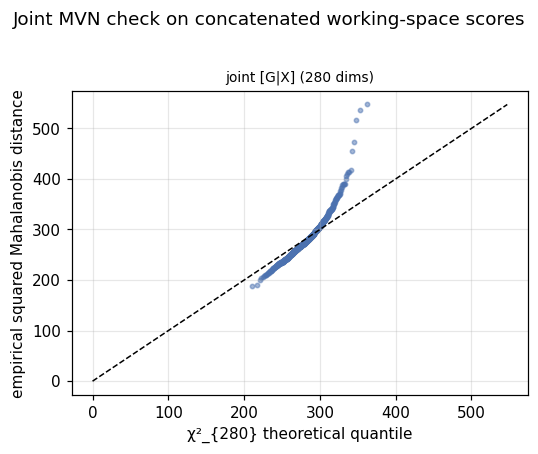


Per-feature marginal normality (raw vs post-copula):
  genomics raw    : |skew|>2 or |kurt|>7 in  24.2% of features (median |skew|=0.91, median |kurt|=1.79)
  genomics post   : |skew|>2 or |kurt|>7 in   0.0% of features (median |skew|=0.00, median |kurt|=0.12)
  imaging raw     : |skew|>2 or |kurt|>7 in  10.1% of features (median |skew|=0.48, median |kurt|=0.93)
  imaging post    : |skew|>2 or |kurt|>7 in   0.0% of features (median |skew|=0.00, median |kurt|=0.12)



Distance correlation dCor(G_pca, X_pca) = 0.318  (perm null mean 0.261, 95% 0.268, p = 0.005)
  -> significant dCor with near-zero CV recoverability would flag nonlinear structure the linear-Gaussian model is blind to.


In [11]:
# --- Upfront model-assumption checks (joint Gaussianity + nonlinearity) -------
# The marginal MVN check above tests each modality separately. The recoverability
# estimator actually assumes (i) the *joint* [G, X] is multivariate normal and
# (ii) the G-X dependence is *linear* (CCA sees nothing else). We test both here,
# plus a per-feature marginal summary that documents why the copula is needed.

# (a) JOINT MVN on the concatenated working-space scores ----------------------
GX_joint = np.column_stack([G_model, X_model])
fig, ax = plt.subplots(figsize=(5, 4))
mvn_joint = _mvn_diagnostic(GX_joint, f"joint [G|X] ({GX_joint.shape[1]} dims)", ax=ax)
fig.suptitle("Joint MVN check on concatenated working-space scores", y=1.02)
plt.tight_layout(); savefig("mvn_joint_diagnostic", fig); plt.show()

# (b) per-feature marginal normality: raw -> post-copula ----------------------
# The copula transform forces each marginal exactly Gaussian; this documents how
# far the RAW marginals were (bimodal probes show as a tail of large |skew|/|kurt|)
# and confirms the transform worked.
def _marg_summary(M, label):
    sk = _st.skew(M, axis=0)
    ku = _st.kurtosis(M, axis=0)  # excess kurtosis; 0 under Gaussian
    frac_bad = float(np.mean((np.abs(sk) > 2) | (np.abs(ku) > 7)))
    print(f"  {label:16s}: |skew|>2 or |kurt|>7 in {frac_bad:6.1%} of features "
          f"(median |skew|={np.median(np.abs(sk)):.2f}, median |kurt|={np.median(np.abs(ku)):.2f})")
    return dict(frac_nonnormal=frac_bad,
                median_abs_skew=float(np.median(np.abs(sk))),
                median_abs_kurt=float(np.median(np.abs(ku))))

print("\nPer-feature marginal normality (raw vs post-copula):")
marg = {
    "genomics_raw":  _marg_summary(G_premarg, "genomics raw"),
    "genomics_post": _marg_summary(G_std,     "genomics post"),
    "imaging_raw":   _marg_summary(X_premarg, "imaging raw"),
    "imaging_post":  _marg_summary(X_std,     "imaging post"),
}

# (c) NON-LINEAR dependence the linear model cannot see -----------------------
# Distance correlation is 0 iff G_pca and X_pca are independent, so it detects
# coupling CCA misses. A significant dCor where the leading CV recoverability is
# ~0 would mean the linear bound understates the true I(G;X).
dcor_obs, dcor_null, dcor_p = rgit.distance_correlation_test(
    G_model, X_model, n_perm=N_PERM, random_state=SEED)
print(f"\nDistance correlation dCor(G_pca, X_pca) = {dcor_obs:.3f}  "
      f"(perm null mean {dcor_null.mean():.3f}, 95% {np.quantile(dcor_null, 0.95):.3f}, "
      f"p = {dcor_p:.3f})")
print("  -> significant dCor with near-zero CV recoverability would flag "
      "nonlinear structure the linear-Gaussian model is blind to.")

stats["assumption_checks"] = {
    "mvn_joint": ({k: float(v) for k, v in mvn_joint.items() if k != "d2"}
                  if mvn_joint else None),
    "per_feature_marginals": marg,
    "distance_correlation": {
        "observed": float(dcor_obs),
        "null_mean": float(dcor_null.mean()),
        "null_q95": float(np.quantile(dcor_null, 0.95)),
        "pvalue": float(dcor_p),
    },
}


In [12]:
# Binarization-gap diagnostic (variant mode only).
# Plots the per-gene entropy loss H(Z_j) - H(G_j) = 0.5*log(2*pi*e) - h_2(p_j)
# against mutation frequency p_j.  This is the slack in the DPI bound
# I(G;X) <= I(Z;X): genes near p = 1/2 are nearly information-preserving
# under binarization; rare-variant genes are highly lossy and make the bound
# loose.  See manuscript Section 'A Bernoulli extension for mutation data'.
if variant_pergene is not None:
    p_hat   = variant_pergene["p_hat"]
    bin_gap = variant_pergene["bin_gap"]
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.scatter(p_hat, bin_gap, s=8, alpha=0.5, color="#4C72B0")
    # reference curve: gap as a function of p
    pp = np.linspace(0.001, 0.999, 400)
    hb = -(pp * np.log(pp) + (1 - pp) * np.log(1 - pp))
    ax.plot(pp, 0.5 * np.log(2 * np.pi * np.e) - hb,
            color="#C44E52", lw=1.2,
            label=r"$\frac{1}{2}\log(2\pi e) - h_2(p)$")
    ax.set_xlabel("mutation frequency $p_j$")
    ax.set_ylabel(r"$H(Z_j) - H(G_j)$  (nats)")
    ax.set_title("Per-gene binarization gap")
    ax.legend(loc="upper right", fontsize=9)
    plt.tight_layout(); savefig("binarization_gap", fig); plt.show()

## 4 · Fit the recoverability model

`rgit.fit_recoverability` forms regularized covariances $\hat\Sigma_G,
\hat\Sigma_X,\hat\Sigma_{GX}$ (Ledoit–Wolf shrinkage by default), builds the
whitened transfer operator $M=\hat\Sigma_G^{-1/2}\hat\Sigma_{GX}\hat\Sigma_X^{-1/2}$,
and reads the canonical correlations $\rho_i$ off its SVD. This *is* regularized
CCA — the recoverability program and CCA are the same computation.

In [13]:
fit = rgit.fit_recoverability(G_model, X_model, n_components=N_COMPONENTS)

spectrum = pd.DataFrame({
    "component":       np.arange(1, fit.n_components + 1),
    "rho":             fit.rho,
    "recoverability":  fit.recoverability,   # R_i = rho_i^2  (in-sample)
})
mi_nats = fit.mutual_information()
print(f"mutual information  I(G;X) = {mi_nats:.2f} nats "
      f"({mi_nats / np.log(2):.2f} bits)")

stats.update({
    "in_sample_rho":            [float(r) for r in fit.rho],
    "in_sample_recoverability": [float(r) for r in fit.recoverability],
    "in_sample_MI_nats":        float(mi_nats),
    "in_sample_MI_bits":        float(mi_nats / np.log(2)),
})
spectrum.round(4)

mutual information  I(G;X) = 4.91 nats (7.08 bits)


,component,rho,recoverability
0,1,0.8736,0.7632
1,2,0.8154,0.6649
2,3,0.7570,0.5731
3,4,0.7448,0.5548
4,5,0.7318,0.5356
5,6,0.7223,0.5217
6,7,0.7184,0.5161
7,8,0.7126,0.5077
8,9,0.7062,0.4988
9,10,0.7026,0.4936


## 5 · Imaging covariance decomposition

The model splits imaging covariance additively,
$\Sigma_X = \underbrace{A\Sigma_G A^\top}_{\text{genomics-driven}} + \underbrace{\sigma^2 I_d}_{\text{irreducible}}$.
`rgit.imaging_variance_explained` reports the genomics-driven share,
$\operatorname{tr}(\Sigma_{XG}\Sigma_G^{-1}\Sigma_{GX})/\operatorname{tr}(\Sigma_X)$.

fraction of imaging variance attributable to genomics
  in-sample (biased when dim ~ n) : 0.279
  cross-validated proxy           : 0.004
irreducible (genomics-independent) share (in-sample): 0.721
saved figure: notebooks/figures/adni/gene_expression/fastsurfer/imaging_variance_decomposition.{pdf,png}


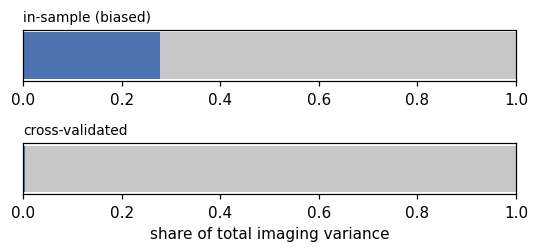

In [14]:
frac, signal_cov = rgit.imaging_variance_explained(fit)

# In-sample frac is biased upward when dim is large relative to n (it counts
# every direction in the genomic span, real or noise). A more honest estimate
# weights only the cross-validated recoverability into the imaging eigenbasis:
# share_signal ~ sum_i R_i^cv * lambda_i(Sx_along_canonical_axis) / tr(Sx).
# As a simple, dimension-aware proxy we report:
#   frac_cv = sum_i R_i^cv  /  min(dim(G), dim(X))
# i.e. the fraction of *recoverable* canonical directions that actually carry
# out-of-sample signal. This is shown alongside the raw in-sample number.

cv_for_frac = rgit.cross_validated_recoverability(
    G_model, X_model, n_components=N_COMPONENTS,
    n_folds=N_FOLDS, random_state=SEED,
).mean(axis=0)
frac_cv = float(np.clip(cv_for_frac, 0, 1).sum()
                / max(1, min(G_model.shape[1], X_model.shape[1])))

print(f"fraction of imaging variance attributable to genomics")
print(f"  in-sample (biased when dim ~ n) : {frac:.3f}")
print(f"  cross-validated proxy           : {frac_cv:.3f}")
print(f"irreducible (genomics-independent) share (in-sample): {1 - frac:.3f}")

stats.update({
    "imaging_var_share_genomics_insample": float(frac),
    "imaging_var_share_genomics_cv":       float(frac_cv),
})

fig, axes = plt.subplots(2, 1, figsize=(5, 2.4))
for ax, value, title in [(axes[0], frac,    "in-sample (biased)"),
                         (axes[1], frac_cv, "cross-validated")]:
    ax.barh([0], [value],     color="#4C72B0")
    ax.barh([0], [1 - value], left=[value], color="#C7C7C7")
    ax.set_xlim(0, 1); ax.set_yticks([])
    ax.set_title(title, fontsize=9, loc="left")
    ax.grid(False)
axes[1].set_xlabel("share of total imaging variance")
plt.tight_layout(); savefig("imaging_variance_decomposition", fig); plt.show()


## 6 · The recoverability spectrum

Each canonical direction $a_i$ has recoverability $R_i=\rho_i^2\in[0,1]$:
$R_i=0$ means imaging carries nothing about that genomic direction, $R_i=1$ means
it is pinned down exactly. The number of appreciably non-zero $R_i$ is the
**dimension of the image-identifiable genomic subspace**.

saved figure: notebooks/figures/adni/gene_expression/fastsurfer/recoverability_spectrum.{pdf,png}


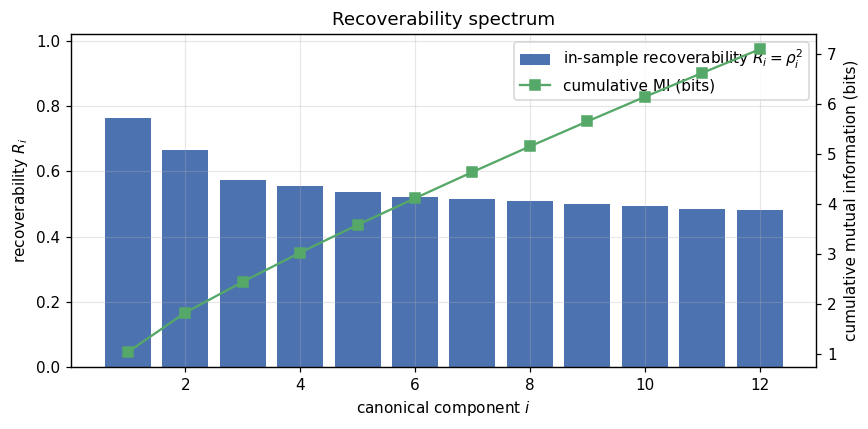

In [15]:
fig, ax1 = plt.subplots(figsize=(8, 4))
comps = spectrum["component"]
ax1.bar(comps, spectrum["recoverability"], color="#4C72B0",
        label="in-sample recoverability $R_i=\\rho_i^2$")
if truth is not None:
    rho_true, R_true = rgit.true_recoverability(truth)
    ax1.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
             R_true[:N_COMPONENTS], "o--", color="#C44E52",
             label="ground-truth $R_i$")
ax1.set_xlabel("canonical component $i$")
ax1.set_ylabel("recoverability $R_i$")
ax1.set_ylim(0, 1.02)

ax2 = ax1.twinx()
ax2.plot(comps, np.cumsum(-0.5 * np.log1p(-fit.rho ** 2)) / np.log(2),
         "s-", color="#55A868", label="cumulative MI (bits)")
ax2.set_ylabel("cumulative mutual information (bits)")
ax2.grid(False)
lines = ax1.get_legend_handles_labels()[0] + ax2.get_legend_handles_labels()[0]
labs  = ax1.get_legend_handles_labels()[1] + ax2.get_legend_handles_labels()[1]
ax1.legend(lines, labs, loc="upper right", frameon=True)
ax1.set_title("Recoverability spectrum")
plt.tight_layout(); savefig("recoverability_spectrum", fig); plt.show()

## 7 · Mutual information budget

$I(G;X)=\sum_i\tfrac12\log(1+\mathrm{SNR}_i)$ — each image-visible genomic
direction contributes $\tfrac12\log(1/(1-\rho_i^2))$ nats. Directions with low
signal-to-noise add almost nothing, regardless of how many genes load on them.

total I(G;X)      : 4.910 nats / 7.084 bits
top component     : 0.720 nats
share in top 6 comps: 58.0%


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/mi_per_direction.{pdf,png}


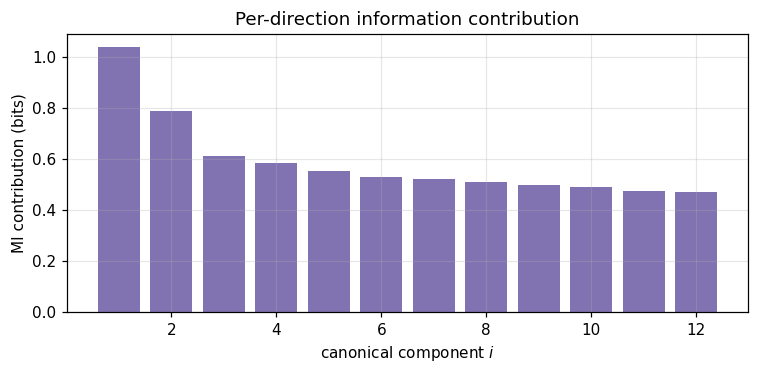

In [16]:
mi_per = -0.5 * np.log1p(-fit.rho ** 2)            # nats per component
print(f"total I(G;X)      : {mi_per.sum():.3f} nats / {mi_per.sum()/np.log(2):.3f} bits")
print(f"top component     : {mi_per[0]:.3f} nats")
print(f"share in top {min(6, fit.n_components)} comps: "
      f"{mi_per[:6].sum() / mi_per.sum():.1%}")

fig, ax = plt.subplots(figsize=(7, 3.5))
ax.bar(spectrum["component"], mi_per / np.log(2), color="#8172B2")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("MI contribution (bits)")
ax.set_title("Per-direction information contribution")
plt.tight_layout(); savefig("mi_per_direction", fig); plt.show()

## 8 · Bayes-optimal predictor and the posterior floor

`rgit.posterior` returns the optimal linear map $B$ ($\,\hat g(x)=Bx\,$) and the
posterior covariance $\Sigma_{G\mid X}$ — the hard floor on residual genomic
uncertainty that **no estimator can beat**. We hold out a test split, predict
genomics from imaging, and check the leading canonical genomic score.

held-out R^2, leading genomic direction : 0.173
median posterior variance retained      : 0.747


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/heldout_recovery.{pdf,png}


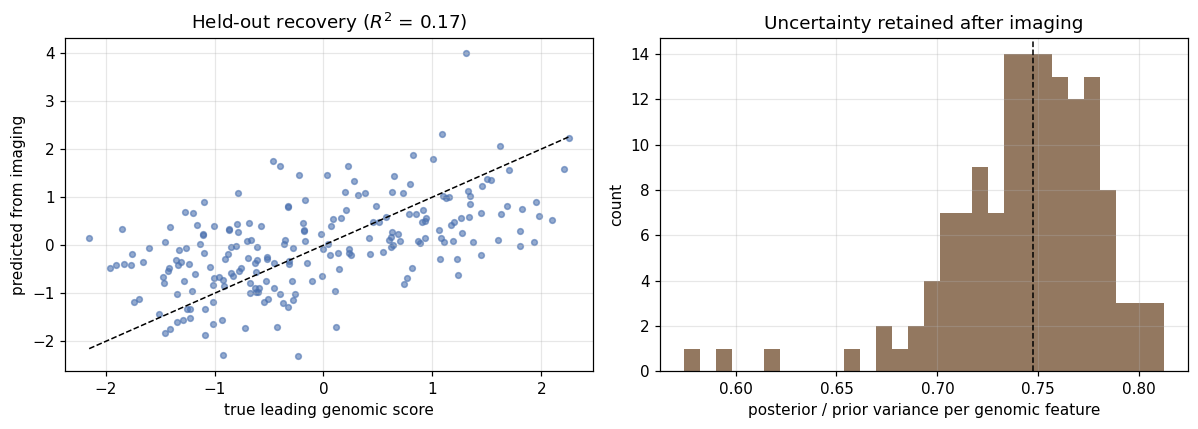

In [17]:
idx = np.arange(G_model.shape[0])
tr, te = train_test_split(idx, test_size=0.3, random_state=SEED)

fit_tr = rgit.fit_recoverability(G_model[tr], X_model[tr], n_components=N_COMPONENTS)
B, Sgcx = rgit.posterior(fit_tr)

# predict genomics from imaging on the held-out split
G_te_c   = G_model[te] - fit_tr.g_mean
X_te_c   = X_model[te] - fit_tr.x_mean
G_te_hat = X_te_c @ B.T

a1            = fit_tr.genomic_dirs[:, 0]               # leading genomic direction
score_true    = G_te_c   @ a1
score_pred    = G_te_hat @ a1
ss_res        = np.sum((score_true - score_pred) ** 2)
ss_tot        = np.sum((score_true - score_true.mean()) ** 2)
r2_heldout    = 1 - ss_res / ss_tot

# variance retained after observing imaging, per genomic feature
var_ratio = np.clip(np.diag(Sgcx) / np.diag(fit_tr.Sg), 0, 1)
print(f"held-out R^2, leading genomic direction : {r2_heldout:.3f}")
print(f"median posterior variance retained      : {np.median(var_ratio):.3f}")

stats.update({
    "heldout_R2_leading_direction":  float(r2_heldout),
    "median_posterior_var_retained": float(np.median(var_ratio)),
})

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(score_true, score_pred, s=14, alpha=0.6, color="#4C72B0")
lim = [score_true.min(), score_true.max()]
axes[0].plot(lim, lim, "k--", lw=1)
axes[0].set_xlabel("true leading genomic score")
axes[0].set_ylabel("predicted from imaging")
axes[0].set_title(f"Held-out recovery ($R^2$ = {r2_heldout:.2f})")

axes[1].hist(var_ratio, bins=30, color="#937860")
axes[1].axvline(np.median(var_ratio), color="k", ls="--", lw=1)
axes[1].set_xlabel("posterior / prior variance per genomic feature")
axes[1].set_ylabel("count")
axes[1].set_title("Uncertainty retained after imaging")
plt.tight_layout(); savefig("heldout_recovery", fig); plt.show()

## 9 · Image-identifiable genomic directions

The recoverability eigenproblem returns the genomic directions $a_i$ imaging
sees best. Reading their loadings back onto genes answers *which biology is
image-identifiable* — leading directions typically align with coarse, spatially
expressed programs rather than individual transcripts.

saved figure: notebooks/figures/adni/gene_expression/fastsurfer/gene_loadings.{pdf,png}


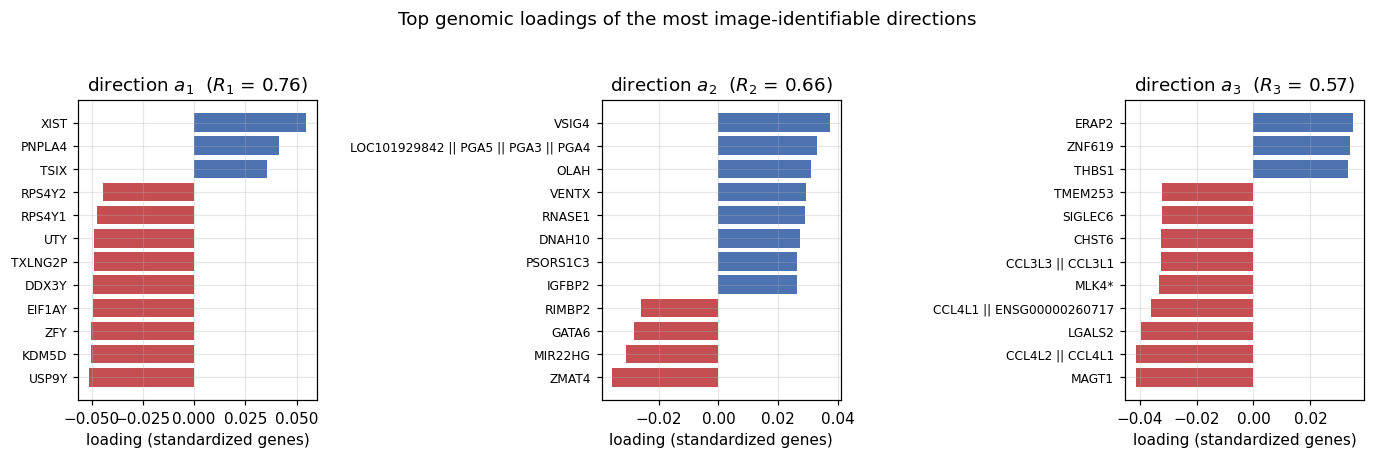

In [18]:
gene_dirs = to_gene_loadings(fit.genomic_dirs)        # (n_genes, n_components)
n_show = min(3, fit.n_components)
top_k  = 12

fig, axes = plt.subplots(1, n_show, figsize=(4.2 * n_show, 4), sharey=False)
axes = np.atleast_1d(axes)
top_loadings_record = {}
for i in range(n_show):
    load = gene_dirs[:, i]
    order = np.argsort(-np.abs(load))[:top_k]
    order = order[np.argsort(load[order])]
    k = len(order)
    colors = ["#C44E52" if v < 0 else "#4C72B0" for v in load[order]]
    axes[i].barh(np.arange(k), load[order], color=colors)
    axes[i].set_yticks(np.arange(k))
    axes[i].set_yticklabels(gene_names[order], fontsize=8)
    axes[i].set_title(f"direction $a_{{{i+1}}}$  ($R_{{{i+1}}}$ = {fit.recoverability[i]:.2f})")
    axes[i].set_xlabel("loading (standardized genes)")
    top_loadings_record[f"a{i+1}"] = [
        {"gene": str(gene_names[j]), "loading": float(load[j])} for j in order[::-1]
    ]
fig.suptitle("Top genomic loadings of the most image-identifiable directions", y=1.03)
plt.tight_layout(); savefig("gene_loadings", fig); plt.show()
stats["top_gene_loadings"] = top_loadings_record

## 9b · Non-linear validation — per-gene predictability

The recoverability theory makes a sharp, falsifiable prediction: genes that
load strongly on highly recoverable directions should be predictable from
imaging, while genes orthogonal to the image-identifiable subspace should
not be — and a flexible non-linear model should not substantially exceed
the linear Bayes-optimal ceiling. We pick a handful of high- vs
low-recoverability mutated genes (per-gene posterior-variance reduction
$1 - \Sigma_{G\mid X,\,jj} / \Sigma_{G,\,jj}$), train an $L_2$ logistic
regression and a small random forest to predict each gene's mutation
status from imaging, and compare 5-fold cross-validated AUC. A clean
AUC gap between the two groups corroborates the spectrum; non-linear
models matching but not exceeding the linear ceiling corroborates the
linear–Gaussian model itself.

                    gene  mut_freq  R_linear            group  AUC_LR  AUC_RF
                     UTY       0.5     0.601     identifiable   0.883   0.864
                    XIST       0.5     0.591     identifiable   0.860   0.850
                  RPS4Y2       0.5     0.588     identifiable   0.766   0.787
                   KDM5D       0.5     0.580     identifiable   0.857   0.856
                  EIF1AY       0.5     0.566     identifiable   0.845   0.849
                 HRASLS2       0.5     0.123 non-identifiable   0.457   0.422
                  INPP5F       0.5     0.128 non-identifiable   0.470   0.468
BLOC1S5-TXNDC5 || TXNDC5       0.5     0.140 non-identifiable   0.448   0.467
                   DOCK7       0.5     0.142 non-identifiable   0.487   0.460
         ENSG00000211895       0.5     0.145 non-identifiable   0.470   0.499

mean AUC by group:
                  AUC_LR  AUC_RF
group                           
identifiable       0.842   0.841
non-identifiable   0.46

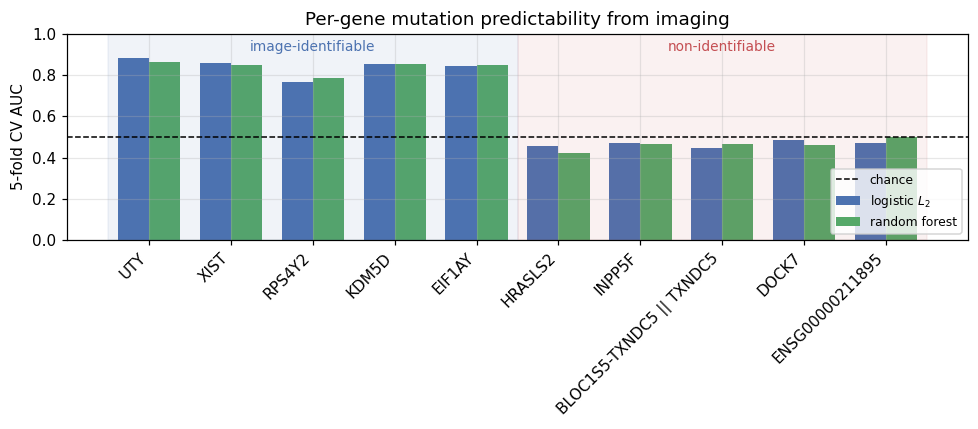

In [19]:
# --- per-gene recoverability in standardized gene space ------------------
_, Sgcx_full = rgit.posterior(fit)
if pca_g is not None:
    W = pca_g.components_                                   # (n_pc, n_genes)
    post_var_gene  = np.einsum("ig,ij,jg->g", W, Sgcx_full, W)
    prior_var_gene = np.einsum("ig,ij,jg->g", W, fit.Sg,    W)
else:
    post_var_gene, prior_var_gene = np.diag(Sgcx_full), np.diag(fit.Sg)
gene_recov = np.clip(1.0 - post_var_gene / np.maximum(prior_var_gene, 1e-12), 0, 1)

# --- pick eligible mutated genes ----------------------------------------
# In variant mode, G_raw has been overwritten with the latent-Gaussian surrogate
# (two real values per gene); fall back to the binary matrix preserved upstream.
if G_bin_global is not None:
    G_bin = G_bin_global.astype(int)
else:
    G_bin = (G_raw > 0).astype(int)
mut_freq = G_bin.mean(axis=0)
MUT_LO, MUT_HI = 0.05, 0.95
eligible = np.where((mut_freq >= MUT_LO) & (mut_freq <= MUT_HI))[0]

# The Bayes AUC ceiling only applies under the latent-Gaussian / multivariate-
# probit model (manuscript Section: 'A Bernoulli extension for mutation data').
# For expression-mode the (>0) binarization is arbitrary and neither
# Phi(sqrt(R/(1-R))/sqrt(2)) nor the homoscedastic-Gaussian posterior used in
# its derivation applies, so the ceiling is suppressed.
show_ceiling = (GENOMICS_DATA_TYPE == "variant")

if len(eligible) < 4:
    print(f"only {len(eligible)} genes mutated in [{MUT_LO:.0%}, {MUT_HI:.0%}] of "
          "patients - skipping per-gene validation.")
else:
    order = eligible[np.argsort(gene_recov[eligible])]
    n_pick     = min(5, len(eligible) // 2)
    low_genes  = order[:n_pick]
    high_genes = order[-n_pick:][::-1]

    def _cv_auc(y, x, n_folds=5):
        skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=SEED)
        a_lr, a_rf = [], []
        for tr, te in skf.split(x, y):
            if len(np.unique(y[te])) < 2:
                continue
            sc = _SS().fit(x[tr])
            lr = LogisticRegression(C=1.0, max_iter=2000,
                                    class_weight="balanced")
            lr.fit(sc.transform(x[tr]), y[tr])
            a_lr.append(roc_auc_score(y[te],
                lr.predict_proba(sc.transform(x[te]))[:, 1]))
            rf = RandomForestClassifier(n_estimators=300, max_depth=4,
                                        min_samples_leaf=3, random_state=SEED,
                                        class_weight="balanced", n_jobs=-1)
            rf.fit(x[tr], y[tr])
            a_rf.append(roc_auc_score(y[te], rf.predict_proba(x[te])[:, 1]))
        return (np.mean(a_lr) if a_lr else np.nan,
                np.mean(a_rf) if a_rf else np.nan)

    # Bayes-optimal AUC ceiling under the latent-Gaussian model:
    #   AUC_max(R) = Phi( sqrt( R / (1-R) ) / sqrt(2) )
    # Only meaningful when G_j is binary and comes from a probit thresholding
    # of a Gaussian latent; otherwise R is variance reduction on a continuous
    # scale and the ceiling formula does not apply.
    def _auc_ceiling(R):
        R = np.clip(R, 0.0, 1.0 - 1e-9)
        return float(_st.norm.cdf(np.sqrt(R / (1.0 - R)) / np.sqrt(2.0)))

    rows = []
    for j in np.concatenate([high_genes, low_genes]):
        auc_lr, auc_rf = _cv_auc(G_bin[:, j], X_model)
        row = {
            "gene":     gene_names[j],
            "mut_freq": mut_freq[j],
            "R_linear": gene_recov[j],
            "group":    "identifiable" if j in high_genes else "non-identifiable",
            "AUC_LR":   auc_lr,
            "AUC_RF":   auc_rf,
        }
        if show_ceiling:
            row["AUC_ceiling"] = _auc_ceiling(gene_recov[j])
        rows.append(row)
    gene_table = pd.DataFrame(rows)
    print(gene_table.round(3).to_string(index=False))

    grp_cols = ["AUC_LR", "AUC_RF"] + (["AUC_ceiling"] if show_ceiling else [])
    grp = gene_table.groupby("group")[grp_cols].mean().round(3)
    print("\nmean AUC by group:"); print(grp)

    stats["per_gene_auc"] = gene_table.assign(
        gene=lambda d: d.gene.astype(str)
    ).to_dict(orient="records")
    stats["per_gene_auc_mean_by_group"] = grp.reset_index().to_dict(orient="records")

    fig, ax = plt.subplots(figsize=(9, 4))
    if show_ceiling:
        xp, w = np.arange(len(gene_table)), 0.30
        ax.bar(xp - w, gene_table["AUC_LR"], w, label="logistic $L_2$", color="#4C72B0")
        ax.bar(xp,     gene_table["AUC_RF"], w, label="random forest",  color="#55A868")
        ax.bar(xp + w, gene_table["AUC_ceiling"], w,
               label=r"Bayes ceiling $\Phi(\sqrt{R/(1-R)}/\sqrt{2})$",
               color="#C44E52", alpha=0.7)
    else:
        xp, w = np.arange(len(gene_table)), 0.38
        ax.bar(xp - w/2, gene_table["AUC_LR"], w, label="logistic $L_2$", color="#4C72B0")
        ax.bar(xp + w/2, gene_table["AUC_RF"], w, label="random forest",  color="#55A868")
    ax.axhline(0.5, color="k", ls="--", lw=1, label="chance")
    ax.set_xticks(xp); ax.set_xticklabels(gene_table["gene"], rotation=45, ha="right")
    ax.set_ylabel("5-fold CV AUC"); ax.set_ylim(0, 1)
    nh = len(high_genes)
    ax.axvspan(-0.5,        nh - 0.5,        alpha=0.08, color="#4C72B0")
    ax.axvspan(nh - 0.5,    len(gene_table)-0.5, alpha=0.08, color="#C44E52")
    ax.text((nh-1)/2,                   0.97, "image-identifiable",
            ha="center", va="top", fontsize=9, color="#4C72B0")
    ax.text((nh + len(gene_table)-1)/2, 0.97, "non-identifiable",
            ha="center", va="top", fontsize=9, color="#C44E52")
    ax.set_title("Per-gene mutation predictability from imaging")
    ax.legend(loc="lower right", fontsize=8); plt.tight_layout()
    savefig("per_gene_auc", fig); plt.show()


## 10 · Honest recoverability — cross-validation

In-sample $\rho_i^2$ is biased upward. `rgit.cross_validated_recoverability`
estimates the canonical directions on each training fold and reports the
**out-of-sample** squared correlation of the projected scores. The gap to the
in-sample curve is the overfitting.

saved figure: notebooks/figures/adni/gene_expression/fastsurfer/cv_recoverability.{pdf,png}


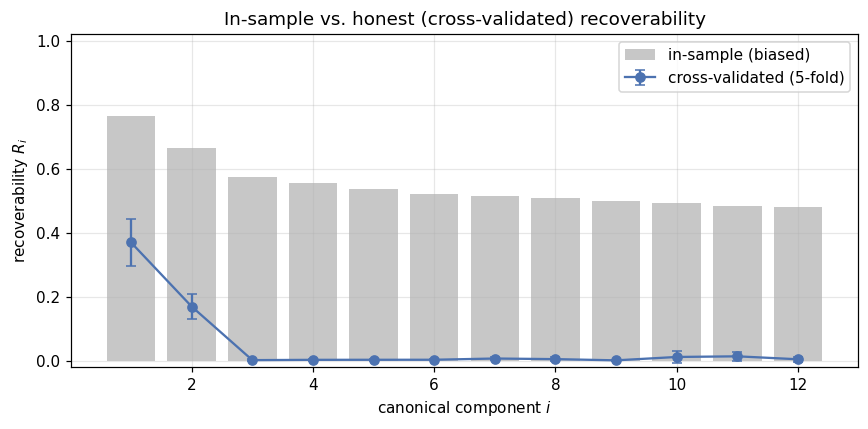

cross-validated recoverability per component:
[0.369 0.169 0.002 0.003 0.003 0.003 0.007 0.005 0.001 0.012 0.014 0.005]


In [20]:
cv = rgit.cross_validated_recoverability(
    G_model, X_model, n_components=N_COMPONENTS,
    n_folds=N_FOLDS, random_state=SEED,
)
cv_mean, cv_std = cv.mean(axis=0), cv.std(axis=0)
comps = spectrum["component"]

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(comps, fit.recoverability, color="#C7C7C7", label="in-sample (biased)")
ax.errorbar(comps, cv_mean, yerr=cv_std, fmt="o-", color="#4C72B0",
            capsize=3, label=f"cross-validated ({N_FOLDS}-fold)")
if truth is not None:
    _, R_true = rgit.true_recoverability(truth)
    ax.plot(np.arange(1, min(len(R_true), N_COMPONENTS) + 1),
            R_true[:N_COMPONENTS], "x--", color="#C44E52", label="ground truth")
ax.set_xlabel("canonical component $i$")
ax.set_ylabel("recoverability $R_i$")
ax.set_ylim(-0.02, 1.02)
ax.set_title("In-sample vs. honest (cross-validated) recoverability")
ax.legend(); plt.tight_layout(); savefig("cv_recoverability", fig); plt.show()

print("cross-validated recoverability per component:")
print(np.array2string(cv_mean, precision=3, suppress_small=True))

stats.update({
    "cv_recoverability_mean": [float(x) for x in cv_mean],
    "cv_recoverability_std":  [float(x) for x in cv_std],
})

## 11 · Permutation test

Permuting patient labels of one modality destroys any real association. The
permutation distribution of the leading canonical correlation gives a null
against which the observed value is tested — does *any* genomic direction beat
chance?

component 1: rho = 0.874   permutation p = 0.0050
component 2: rho = 0.815   permutation p = 0.0050
component 3: rho = 0.757   permutation p = 0.0050


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/permutation_null.{pdf,png}


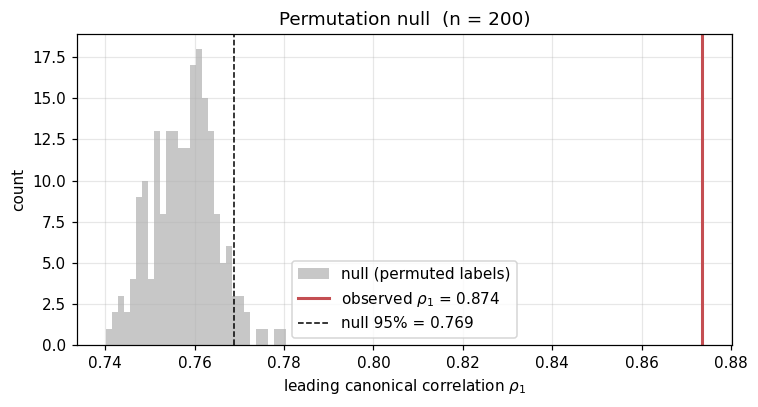

In [21]:
observed, null, pvalues = rgit.permutation_test(
    G_model, X_model, n_components=min(3, N_COMPONENTS),
    n_perm=N_PERM, random_state=SEED,
)
for i, (o, p) in enumerate(zip(observed, pvalues), start=1):
    print(f"component {i}: rho = {o:.3f}   permutation p = {p:.4f}")

stats["permutation"] = {
    "n_perm":     int(N_PERM),
    "observed":   [float(x) for x in observed],
    "p_values":   [float(x) for x in pvalues],
    "null_rho1_mean":     float(null[:, 0].mean()),
    "null_rho1_q95":      float(np.quantile(null[:, 0], 0.95)),
    "null_rho1_q99":      float(np.quantile(null[:, 0], 0.99)),
}

fig, ax = plt.subplots(figsize=(7, 3.8))
ax.hist(null[:, 0], bins=30, color="#C7C7C7", label="null (permuted labels)")
ax.axvline(observed[0], color="#C44E52", lw=2,
           label=f"observed $\\rho_1$ = {observed[0]:.3f}")
ax.axvline(np.quantile(null[:, 0], 0.95), color="k", ls="--", lw=1,
           label=f"null 95% = {np.quantile(null[:, 0], 0.95):.3f}")
ax.set_xlabel("leading canonical correlation $\\rho_1$")
ax.set_ylabel("count")
ax.set_title(f"Permutation null  (n = {N_PERM})")
ax.legend(); plt.tight_layout(); savefig("permutation_null", fig); plt.show()

## 11b · Upper-bound on $I(G;X)$ from the permutation null

When the leading canonical correlation does not separate from its null, the
right summary is not "we failed to detect signal" but **"the channel capacity
in this cohort is bounded above"**. We build a permutation distribution for
the cumulative mutual information over the top-$K$ canonical directions
and read off its 95th percentile as a one-sided upper confidence limit on
$I(G;X)$ — a quoteable, falsifiable empirical ceiling. We also report the
**effective image-identifiable rank**: the number of canonical components
whose cross-validated $R_i$ exceeds the per-component permutation-null 95%
quantile. This is the empirical instantiation of the rank bound of
Proposition~\ref{prop:rank} after sample-size deflation.

observed cumulative MI (top-3):  1.692 nats / 2.442 bits
null mean cumulative MI (top-3): 1.228 nats
95% upper confidence bound on I(G;X):     1.269 nats / 1.830 bits


honest effective image-identifiable rank (CV-R > CV-R null 95% & perm p<0.05): 2 of 3 tested
  CV-R observed : [0.369 0.169 0.002]
  CV-R null 95% : [0.014 0.015 0.016]
  CV-R perm p   : [0.005 0.005 0.925]


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/mi_upper_bound.{pdf,png}


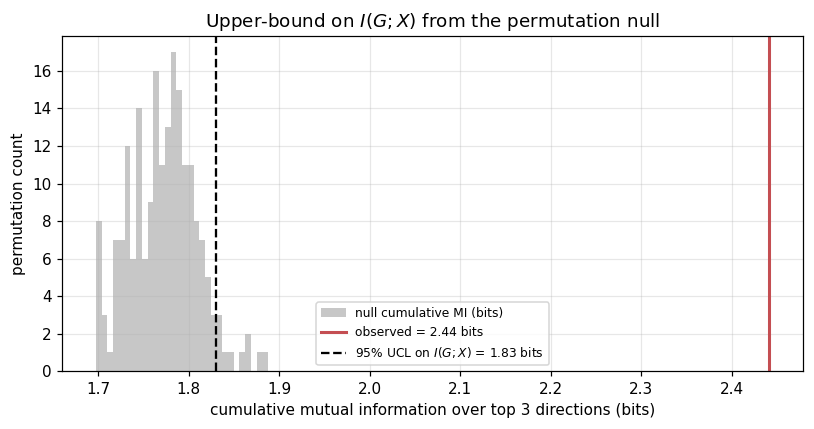

In [22]:
# --- upper confidence bound on I(G;X) from the permutation null ---------
# Each permutation gives a leading rho_1 under the null; for each component i we
# already have a per-component null draw from `permutation_test`. We aggregate
# them into a null distribution on the cumulative mutual information
#   MI_null(K) = -0.5 * sum_{i<=K} log(1 - rho_i^null^2)
# and report the 95% upper quantile as a one-sided UCL on the observed MI.
# This converts the null finding into a quoteable bound: "with 95% confidence,
# I(G;X) does not exceed UCL_95 bits in this cohort."

K_for_ucl   = null.shape[1]
mi_null_K   = -0.5 * np.sum(np.log1p(-np.clip(null, 0, 1 - 1e-12) ** 2), axis=1)
mi_obs_K    = float(-0.5 * np.sum(np.log1p(-np.clip(observed, 0, 1 - 1e-12) ** 2)))
mi_ucl_nats = float(np.quantile(mi_null_K, 0.95))
mi_ucl_bits = mi_ucl_nats / np.log(2)

print(f"observed cumulative MI (top-{K_for_ucl}):  {mi_obs_K:.3f} nats / "
      f"{mi_obs_K / np.log(2):.3f} bits")
print(f"null mean cumulative MI (top-{K_for_ucl}): {mi_null_K.mean():.3f} nats")
print(f"95% upper confidence bound on I(G;X):     {mi_ucl_nats:.3f} nats / "
      f"{mi_ucl_bits:.3f} bits")

# Effective image-identifiable rank, the honest way. The in-sample-rho
# permutation null above is inflated toward 1 by high-dimensional geometry, so
# comparing the deflated CV-R against it forces rank 0. Instead we build a
# permutation null of the *same* cross-validated statistic (rgit.cv_permutation_test)
# and count components whose held-out R clears their own null and are
# permutation-significant. This is the scale-matched test (see manuscript).
cv_obs, cv_null, cv_pvals = rgit.cv_permutation_test(
    G_model, X_model, n_components=K_for_ucl,
    n_perm=N_PERM, n_folds=N_FOLDS, random_state=SEED,
)
cv_null_q95 = np.quantile(cv_null, 0.95, axis=0)
eff_rank    = int(np.sum((cv_obs > cv_null_q95) & (cv_pvals < 0.05)))
print(f"honest effective image-identifiable rank "
      f"(CV-R > CV-R null 95% & perm p<0.05): {eff_rank} of {K_for_ucl} tested")
print(f"  CV-R observed : {np.array2string(cv_obs, precision=3, suppress_small=True)}")
print(f"  CV-R null 95% : {np.array2string(cv_null_q95, precision=3, suppress_small=True)}")
print(f"  CV-R perm p   : {np.array2string(cv_pvals, precision=3, suppress_small=True)}")
# legacy (inflated) comparison kept for reference
null_R_q95 = np.quantile(null ** 2, 0.95, axis=0)

stats["mi_upper_bound"] = {
    "K":              int(K_for_ucl),
    "observed_nats":  float(mi_obs_K),
    "observed_bits":  float(mi_obs_K / np.log(2)),
    "ucl_95_nats":    float(mi_ucl_nats),
    "ucl_95_bits":    float(mi_ucl_bits),
    "null_mean_nats": float(mi_null_K.mean()),
}
stats["effective_identifiable_rank"] = {
    "K_tested":            int(K_for_ucl),
    "rank":                eff_rank,
    "method":              "cv_permutation",
    "cv_R_observed":       [float(x) for x in cv_obs],
    "cv_R_null_q95":       [float(x) for x in cv_null_q95],
    "cv_R_perm_pvalues":   [float(x) for x in cv_pvals],
    "legacy_inflated_null_R_q95": [float(x) for x in null_R_q95],
}

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.hist(mi_null_K / np.log(2), bins=30, color="#C7C7C7",
        label="null cumulative MI (bits)")
ax.axvline(mi_obs_K / np.log(2), color="#C44E52", lw=2,
           label=f"observed = {mi_obs_K/np.log(2):.2f} bits")
ax.axvline(mi_ucl_bits, color="k", ls="--", lw=1.5,
           label=f"95% UCL on $I(G;X)$ = {mi_ucl_bits:.2f} bits")
ax.set_xlabel(f"cumulative mutual information over top {K_for_ucl} directions (bits)")
ax.set_ylabel("permutation count")
ax.set_title("Upper-bound on $I(G;X)$ from the permutation null")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); savefig("mi_upper_bound", fig); plt.show()

In [ ]:
# --- preprocessing-robustness sweep -------------------------------------
# The CV-R magnitude depends on expression layer and HVG method; the permutation
# significance should not. We re-run the honest pipeline over a small grid of
# defensible preprocessing choices (expression layer x HVG method x seed) and
# record the invariant quantities to stats.json, so the manuscript can quote a
# range rather than a single config. Skipped for non-expression genomics.
if GENOMICS_DATA_TYPE == "expression" and not USE_SYNTHETIC:
    _gen0 = ad.read_h5ad(GENOMICS_H5AD)
    _img0 = ad.read_h5ad(IMAGING_H5AD)
    _common = sorted(set(_gen0.obs_names) & set(_img0.obs_names))
    _gen0 = _gen0[_common].copy(); _img0 = _img0[_common].copy()
    _Xc = rgit.gaussian_rank_transform(rgit.to_dense(_img0.X))
    _n = len(_common); _ps = max(MIN_WORKING_DIM, _n // SAMPLES_PER_DIM)
    _pg = min(_ps, _n - 1); _pd = min(_ps, _Xc.shape[1], _n - 1)
    _layers = [L for L in ("unstranded", "tpm_unstranded") if L in _gen0.layers] or ["__X__"]

    def _prep_g(layer, hvg):
        g = _gen0.copy()
        M = rgit.to_dense(g.layers[layer]) if layer != "__X__" else rgit.to_dense(g.X)
        M = np.nan_to_num(M.astype(np.float32), nan=0.0); g.X = M
        g = g[:, (M > 0).sum(0) >= MIN_EXPRESSED_PATIENTS].copy()
        sc.pp.normalize_total(g, target_sum=1e6); g.X = np.log1p(g.X)
        if hvg == "scanpy":
            sc.pp.highly_variable_genes(g, n_top_genes=2000, subset=True); Mo = rgit.to_dense(g.X)
        else:
            Mo = rgit.to_dense(g.X); Mo = Mo[:, np.argsort(Mo.var(0))[::-1][:2000]]
        return rgit.gaussian_rank_transform(Mo)

    _Xs = PCA(_pd, random_state=SEED).fit_transform(StandardScaler().fit_transform(_Xc))
    _minp, _bestcvr, _ranks, _cfgs = [], [], [], []
    for _layer in _layers:
        for _hvg in ("scanpy", "variance"):
            _Gs = PCA(_pg, random_state=SEED).fit_transform(
                StandardScaler().fit_transform(_prep_g(_layer, _hvg)))
            for _seed in range(3):
                _, _, _pv = rgit.permutation_test(_Gs, _Xs, n_components=3, n_perm=100, random_state=_seed)
                _obs, _nullcv, _pcv = rgit.cv_permutation_test(
                    _Gs, _Xs, n_components=3, n_perm=100, n_folds=N_FOLDS, random_state=_seed)
                _rank = int(np.sum((_obs > np.quantile(_nullcv, 0.95, 0)) & (_pcv < 0.05)))
                _minp.append(float(_pv.min())); _bestcvr.append(float(_obs.max())); _ranks.append(_rank)
                _cfgs.append(f"{_layer}/{_hvg}/s{_seed}")
    _minp = np.array(_minp); _bestcvr = np.array(_bestcvr); _ranks = np.array(_ranks)
    stats["preprocessing_robustness"] = {
        "n_configs":            len(_ranks),
        "grid":                 "expr-layer x {scanpy,variance}-HVG x 3 seeds",
        "p_star": int(_pg), "d_star": int(_pd),
        "min_perm_p_median":    float(np.median(_minp)),
        "min_perm_p_range":     [float(_minp.min()), float(_minp.max())],
        "frac_perm_p_lt_0.05":  float(np.mean(_minp < 0.05)),
        "best_cv_R_median":     float(np.median(_bestcvr)),
        "best_cv_R_range":      [float(_bestcvr.min()), float(_bestcvr.max())],
        "eff_rank_median":      int(np.median(_ranks)),
        "eff_rank_range":       [int(_ranks.min()), int(_ranks.max())],
        "frac_eff_rank_ge_1":   float(np.mean(_ranks >= 1)),
    }
    print("preprocessing robustness ({} configs): perm-p<0.05 in {:.0%}, "
          "best CV-R median {:.3f} [{:.3f},{:.3f}], eff-rank median {} [{},{}]".format(
        len(_ranks), stats["preprocessing_robustness"]["frac_perm_p_lt_0.05"],
        np.median(_bestcvr), _bestcvr.min(), _bestcvr.max(),
        int(np.median(_ranks)), _ranks.min(), _ranks.max()))
else:
    print("preprocessing-robustness sweep skipped (non-expression or synthetic)")


preprocessing robustness (6 configs): perm-p<0.05 in 100%, best CV-R median 0.312 [0.283,0.359], eff-rank median 2 [2,2]


## 11f · Demographic deconfounding — with vs. without

Regressing age, sex and education out of both modalities tests whether the
image-identifiable channel is a genuine molecular association or a demographic
artefact. Both spectra are reported regardless of the `DECONFOUND` flag.

raw          : CV-R1=0.369  CV-R2=0.169  eff_rank=2
deconfounded : CV-R1=0.006  CV-R2=0.005  eff_rank=0  (2% of raw R1 retained)


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/deconfound_comparison.{pdf,png}


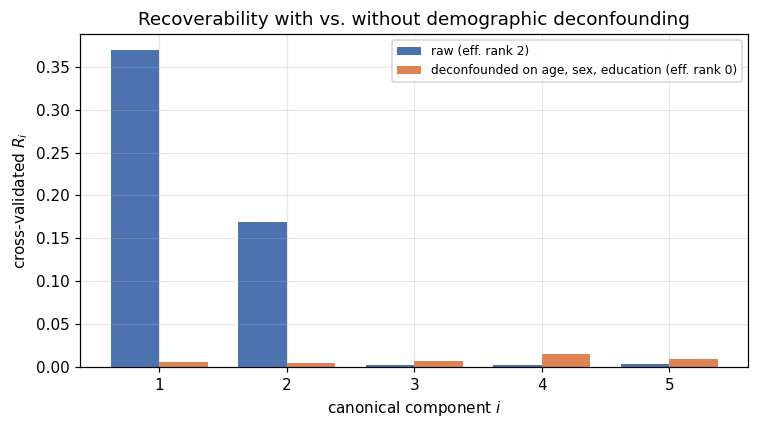

In [24]:
# --- with vs without demographic deconfounding (always shows both) -------
# Answers "is the recoverability a real molecular signal or an age/sex artefact?"
# by comparing the honest CV recoverability spectrum on the raw modeling
# matrices against the same matrices with the demographic confounders regressed
# out of both modalities. Independent of the DECONFOUND flag.
if C_full is not None and not USE_SYNTHETIC:
    def _honest_spectrum(Gm, Xm):
        nc = max(1, min(N_COMPONENTS_MAX, Gm.shape[1], Xm.shape[1]))
        cv = rgit.cross_validated_recoverability(
            Gm, Xm, n_components=nc, n_folds=N_FOLDS, random_state=SEED).mean(0)
        obs, nullcv, pcv = rgit.cv_permutation_test(
            Gm, Xm, n_components=3, n_perm=200, n_folds=N_FOLDS, random_state=SEED)
        rank = int(np.sum((obs > np.quantile(nullcv, 0.95, 0)) & (pcv < 0.05)))
        return cv, rank, [float(x) for x in pcv]

    Gd, Xd = residualize(G_model_raw, C_full), residualize(X_model_raw, C_full)
    cv_raw, rank_raw, p_raw = _honest_spectrum(G_model_raw, X_model_raw)
    cv_dec, rank_dec, p_dec = _honest_spectrum(Gd, Xd)

    stats["deconfound_comparison"] = {
        "confounders":  conf_cols,
        "raw":          {"cv_R": [float(x) for x in cv_raw[:5]], "eff_rank": rank_raw, "cv_perm_p": p_raw},
        "deconfounded": {"cv_R": [float(x) for x in cv_dec[:5]], "eff_rank": rank_dec, "cv_perm_p": p_dec},
        "retained_frac_R1": float(cv_dec[0] / cv_raw[0]) if cv_raw[0] > 0 else None,
    }
    print(f"raw          : CV-R1={cv_raw[0]:.3f}  CV-R2={cv_raw[1]:.3f}  eff_rank={rank_raw}")
    print(f"deconfounded : CV-R1={cv_dec[0]:.3f}  CV-R2={cv_dec[1]:.3f}  eff_rank={rank_dec}  "
          f"({100*cv_dec[0]/max(cv_raw[0],1e-9):.0f}% of raw R1 retained)")

    K = 5
    fig, ax = plt.subplots(figsize=(7, 4)); x = np.arange(1, K + 1); w = 0.38
    ax.bar(x - w/2, cv_raw[:K], w, color="#4C72B0", label=f"raw (eff. rank {rank_raw})")
    ax.bar(x + w/2, cv_dec[:K], w, color="#DD8452",
           label=f"deconfounded on {', '.join(conf_cols)} (eff. rank {rank_dec})")
    ax.set_xlabel("canonical component $i$"); ax.set_ylabel(r"cross-validated $R_i$")
    ax.set_xticks(x)
    ax.set_title("Recoverability with vs. without demographic deconfounding")
    ax.legend(fontsize=8); plt.tight_layout(); savefig("deconfound_comparison", fig); plt.show()
else:
    print("deconfound comparison skipped (no confounders / synthetic)")


## 11c · Sample-complexity sweep

A null result at one $n$ is not very informative on its own. What we want to
know is: *how would the recoverability spectrum behave if the cohort were
larger or smaller?* Subsampling the cohort to a grid of sizes and refitting
gives an empirical answer — and lets us convert "we see nothing here" into
the operationally useful "to see a recoverability of $R_1$, this cohort would
need $n \gtrsim N^\star$ patients." We compare three curves vs.\ $n$: the
biased in-sample $\rho_1^2$, the honest cross-validated $R_1$, and the
permutation-null 95% threshold (the level $\rho_1^2$ must clear to register
as anything but chance), alongside the closed-form Wachter detection edge
$(\sqrt{\kappa_G(1-\kappa_X)} + \sqrt{\kappa_X(1-\kappa_G)})^2$ from
Section~\ref{sec:estimation-regimes} of the manuscript.

  n  p_star  d_star  rho1_insample  R1_cv  MI_nats  null_rho1_q95  wachter_edge
 50      10      10          0.768  0.181    1.319          0.786         0.640
211      42      42          0.847  0.206    3.692          0.761         0.638
351      70      70          0.856  0.277    4.260          0.763         0.639
491      98      98          0.875  0.338    4.645          0.762         0.639
597     119     119          0.859  0.269    4.689          0.765         0.638
702     140     140          0.869  0.332    4.918          0.770         0.639


saved figure: notebooks/figures/adni/gene_expression/fastsurfer/sample_complexity_sweep.{pdf,png}


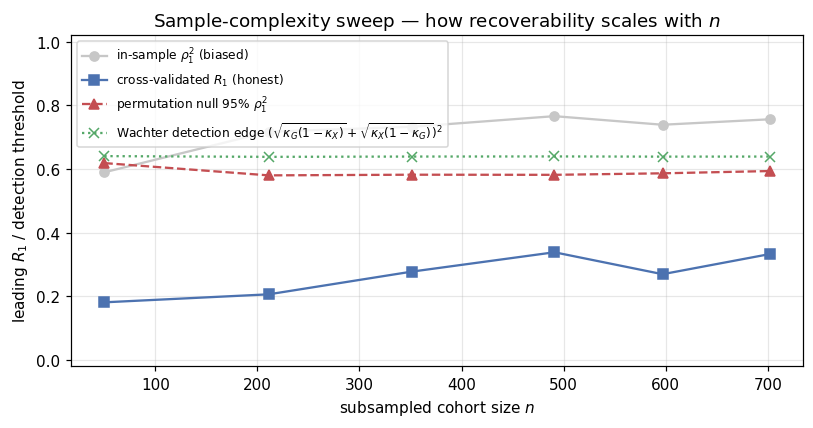

In [25]:
# --- sample-complexity sweep: how does CV-recoverability scale with n? ---
# At each target n we draw a fixed random subsample, refit the working pipeline
# (same per-modality PCA budget, same fold count), and record:
#   - in-sample rho_1
#   - cross-validated R_1  (the honest leading recoverability)
#   - the permutation-null 95% threshold for rho_1
# A real signal should pull CV-R_1 above zero as n grows; a noise-only channel
# stays near zero across the range. We also overlay an asymptotic detection
# floor from the Wachter / Bai-Yao bulk-edge:
#   rho_1^2 must exceed (sqrt(kg(1-kx)) + sqrt(kx(1-kg)))^2,  kg=p*/n, kx=d*/n
# to be detectable above the high-dimensional null edge.

def _wachter_edge(p_star, d_star, n):
    kg, kx = p_star / n, d_star / n
    if kg + kx >= 1:
        return 1.0
    return float((np.sqrt(kg * (1 - kx)) + np.sqrt(kx * (1 - kg))) ** 2)

# fix the original-feature working matrices we'll subsample from
G_full_std = G_std            # (n, p_native)
X_full_std = X_std            # (n, d_native)
n_full     = G_full_std.shape[0]

sweep_grid = sorted({int(round(f * n_full)) for f in (0.3, 0.5, 0.7, 0.85, 1.0)}
                    | {50} if n_full >= 60 else {n_full})
sweep_grid = [n for n in sweep_grid if 30 <= n <= n_full]

sweep_rows = []
sweep_rng  = np.random.default_rng(SEED + 1)
N_PERM_SWEEP = 100

for n_sub in sweep_grid:
    sel = sweep_rng.choice(n_full, size=n_sub, replace=False)
    Gs  = G_full_std[sel]
    Xs  = X_full_std[sel]

    # rebuild per-modality reduction with the same SAMPLES_PER_DIM rule
    budget = max(MIN_WORKING_DIM, n_sub // SAMPLES_PER_DIM)
    p_star = min(Gs.shape[1], n_sub - 1, budget)
    d_star = min(Xs.shape[1], n_sub - 1, budget)
    pg = PCA(n_components=p_star, random_state=SEED).fit(Gs)
    px = PCA(n_components=d_star, random_state=SEED).fit(Xs)
    Gm = pg.transform(Gs)
    Xm = px.transform(Xs)

    ncomp = max(1, min(N_COMPONENTS_MAX, p_star, d_star, n_sub - 1))
    fit_s = rgit.fit_recoverability(Gm, Xm, n_components=ncomp)

    cv_s = rgit.cross_validated_recoverability(
        Gm, Xm, n_components=ncomp,
        n_folds=min(N_FOLDS, n_sub // 10) or 2,
        random_state=SEED,
    ).mean(axis=0)

    obs_s, null_s, _ = rgit.permutation_test(
        Gm, Xm, n_components=1, n_perm=N_PERM_SWEEP, random_state=SEED,
    )

    sweep_rows.append({
        "n":              int(n_sub),
        "p_star":         int(p_star),
        "d_star":         int(d_star),
        "rho1_insample":  float(fit_s.rho[0]),
        "R1_cv":          float(cv_s[0]),
        "MI_nats":        float(fit_s.mutual_information()),
        "null_rho1_q95":  float(np.quantile(null_s[:, 0], 0.95)),
        "wachter_edge":   _wachter_edge(p_star, d_star, n_sub),
    })

sweep = pd.DataFrame(sweep_rows)
print(sweep.round(3).to_string(index=False))

stats["sample_complexity_sweep"] = sweep.to_dict(orient="records")

fig, ax = plt.subplots(figsize=(7.5, 4))
ax.plot(sweep["n"], sweep["rho1_insample"] ** 2, "o-", color="#C7C7C7",
        label=r"in-sample $\rho_1^2$ (biased)")
ax.plot(sweep["n"], sweep["R1_cv"], "s-", color="#4C72B0",
        label=r"cross-validated $R_1$ (honest)")
ax.plot(sweep["n"], sweep["null_rho1_q95"] ** 2, "^--", color="#C44E52",
        label=r"permutation null 95% $\rho_1^2$")
ax.plot(sweep["n"], sweep["wachter_edge"], "x:", color="#55A868",
        label=r"Wachter detection edge $(\sqrt{\kappa_G(1-\kappa_X)}+\sqrt{\kappa_X(1-\kappa_G)})^2$")
ax.set_xlabel("subsampled cohort size $n$")
ax.set_ylabel(r"leading $R_1$ / detection threshold")
ax.set_ylim(-0.02, 1.02)
ax.set_title("Sample-complexity sweep — how recoverability scales with $n$")
ax.legend(loc="best", fontsize=8)
plt.tight_layout(); savefig("sample_complexity_sweep", fig); plt.show()

## 11e · Downsampling: how much data do we need?

Holding the working dimension fixed, we scan subsample sizes and track the
honest leading recoverability, raw and demographic-deconfounded, against the
permutation null — an operational answer to how large a cohort is required.

  n  frac  R1_cv_raw  null95  R1_cv_deconfounded
 70 0.100      0.060   0.904               0.056
140 0.199      0.151   0.602               0.025
246 0.350      0.324   0.392               0.070
351 0.500      0.318   0.303               0.024
491 0.699      0.370   0.228               0.058
597 0.850      0.377   0.188               0.024
702 1.000      0.392   0.162               0.011
saved figure: notebooks/figures/adni/gene_expression/fastsurfer/downsample_recoverability.{pdf,png}


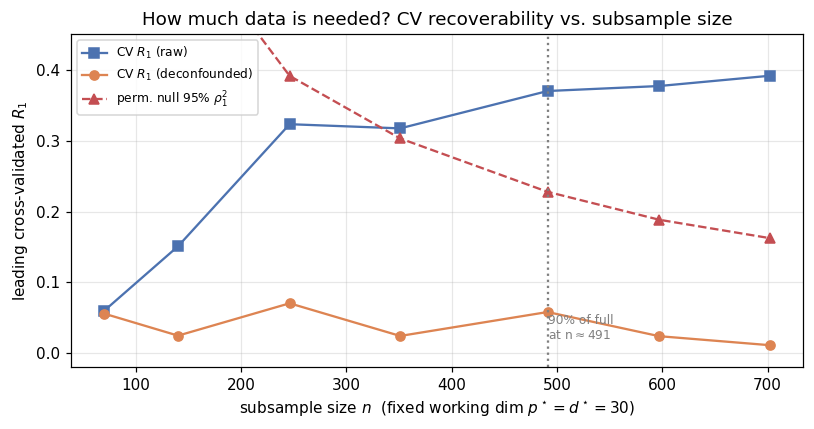

In [26]:
# --- downsampling sweep: how much of the cohort do we actually need? -----
# The sample-complexity sweep above grows the working dimension p*,d* with n,
# which entangles "more data" with "bigger model". Here we hold the working
# dimension FIXED across subsample sizes, so the only thing varying is n. We
# scan DOWNSAMPLE_FRACS of the cohort, refit at fixed p*=d*=DOWN_DIM, and plot
# the honest leading CV-R_1 (raw and, where available, demographic-deconfounded)
# vs n, with the permutation 95% threshold. The dashed line marks the smallest n
# reaching 90% of the full-cohort CV-R_1 -- an operational "data needed" readout.
if not USE_SYNTHETIC:
    DOWN_DIM  = int(min(G_model_raw.shape[1], X_model_raw.shape[1], 30))
    down_rng  = np.random.default_rng(SEED + 7)
    n_full_d  = G_model_raw.shape[0]
    sizes = sorted({max(40, int(round(f * n_full_d))) for f in DOWNSAMPLE_FRACS})
    sizes = [n for n in sizes if n <= n_full_d]

    def _fixed_cvr1(Gm, Xm, n_sub, sel):
        Gs = PCA(DOWN_DIM, random_state=SEED).fit_transform(Gm[sel])
        Xs = PCA(DOWN_DIM, random_state=SEED).fit_transform(Xm[sel])
        cv = rgit.cross_validated_recoverability(
            Gs, Xs, n_components=3, n_folds=min(N_FOLDS, n_sub // 10) or 2,
            random_state=SEED).mean(0)
        _, nulls, _ = rgit.permutation_test(Gs, Xs, n_components=1, n_perm=100, random_state=SEED)
        return float(cv[0]), float(np.quantile(nulls[:, 0], 0.95) ** 2)

    have_dec = C_full is not None
    Gdec = residualize(G_model_raw, C_full) if have_dec else None
    Xdec = residualize(X_model_raw, C_full) if have_dec else None

    down_rows = []
    for n_sub in sizes:
        sel = down_rng.choice(n_full_d, size=n_sub, replace=False)
        r_raw, thr = _fixed_cvr1(G_model_raw, X_model_raw, n_sub, sel)
        row = {"n": n_sub, "frac": round(n_sub / n_full_d, 3), "R1_cv_raw": r_raw, "null95": thr}
        if have_dec:
            row["R1_cv_deconfounded"], _ = _fixed_cvr1(Gdec, Xdec, n_sub, sel)
        down_rows.append(row)
    down = pd.DataFrame(down_rows)
    print(down.round(3).to_string(index=False))

    full_r1  = down["R1_cv_raw"].iloc[-1]
    reach    = down[down["R1_cv_raw"] >= 0.9 * full_r1]
    n_needed = int(reach["n"].iloc[0]) if len(reach) else None
    stats["downsample_sweep"] = {"working_dim": DOWN_DIM,
                                 "rows": down.to_dict(orient="records"),
                                 "n_for_90pct_full_R1": n_needed}

    fig, ax = plt.subplots(figsize=(7.5, 4))
    ax.plot(down["n"], down["R1_cv_raw"], "s-", color="#4C72B0", label=r"CV $R_1$ (raw)")
    if have_dec:
        ax.plot(down["n"], down["R1_cv_deconfounded"], "o-", color="#DD8452",
                label=r"CV $R_1$ (deconfounded)")
    ax.plot(down["n"], down["null95"], "^--", color="#C44E52", label=r"perm. null 95% $\rho_1^2$")
    if n_needed is not None:
        ax.axvline(n_needed, ls=":", color="gray")
        ax.annotate(f"90% of full\nat n$\\approx${n_needed}", (n_needed, 0.02),
                    fontsize=8, color="gray", ha="left")
    ax.set_xlabel(r"subsample size $n$  (fixed working dim $p^\star=d^\star=%d$)" % DOWN_DIM)
    ax.set_ylabel(r"leading cross-validated $R_1$")
    ax.set_title("How much data is needed? CV recoverability vs. subsample size")
    _rcols = [c for c in down.columns if c.startswith("R1")]
    ax.set_ylim(-0.02, max(0.4, float(down[_rcols].values.max()) * 1.15))
    ax.legend(fontsize=8); plt.tight_layout(); savefig("downsample_recoverability", fig); plt.show()
else:
    print("downsample sweep skipped (synthetic)")


## 11d · Export statistics for the manuscript

All accumulated statistics — cohort dimensions, in-sample and cross-validated
spectra, mutual-information bounds, permutation-null summaries, the
sample-complexity sweep — are written to `stats.json` alongside the figures so
the manuscript can quote them directly.

In [27]:
# Dump all accumulated statistics for use by the manuscript.
with open(STATS_PATH, "w") as f:
    json.dump(stats, f, indent=2, default=float)

print(f"wrote {STATS_PATH.relative_to(REPO_ROOT)}")
print(f"keys: {list(stats.keys())}")

wrote notebooks/figures/adni/gene_expression/fastsurfer/stats.json
keys: ['genomics_h5ad', 'imaging_h5ad', 'genomics_stem', 'imaging_stem', 'n_samples', 'p_native_genes', 'd_native_feats', 'dim_g_model', 'dim_x_model', 'n_components', 'confounders', 'assumption_checks', 'in_sample_rho', 'in_sample_recoverability', 'in_sample_MI_nats', 'in_sample_MI_bits', 'imaging_var_share_genomics_insample', 'imaging_var_share_genomics_cv', 'heldout_R2_leading_direction', 'median_posterior_var_retained', 'top_gene_loadings', 'per_gene_auc', 'per_gene_auc_mean_by_group', 'cv_recoverability_mean', 'cv_recoverability_std', 'permutation', 'mi_upper_bound', 'effective_identifiable_rank', 'preprocessing_robustness', 'deconfound_comparison', 'sample_complexity_sweep', 'downsample_sweep']


## 12 · Validation against ground truth

Run only on synthetic data, where the generative parameters are known. We
compare the estimated recoverability spectrum to the closed-form truth, and
measure how well the estimated image-identifiable subspace aligns with the true
shared subspace via the cosines of the principal angles.

In [28]:
if truth is None:
    print("Real data loaded — no ground truth available; skipping validation.")
else:
    rho_true, R_true = rgit.true_recoverability(truth)
    k = truth["k"]

    # estimated subspace vs. true shared genomic subspace
    est_dirs  = to_gene_loadings(fit.genomic_dirs[:, :k])   # (n_genes, k)
    cos_ang   = rgit.subspace_alignment(est_dirs, truth["Wg"])

    print(f"true shared rank k                 : {k}")
    print(f"true   R (first {k+2})            : "
          f"{np.array2string(R_true[:k+2], precision=3, suppress_small=True)}")
    print(f"CV     R (first {k+2})            : "
          f"{np.array2string(cv_mean[:k+2], precision=3, suppress_small=True)}")
    print(f"subspace alignment (cos angles)    : "
          f"{np.array2string(cos_ang, precision=3)}")
    print(f"mean alignment over true subspace  : {cos_ang.mean():.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(11, 4))
    axes[0].plot(np.arange(1, k + 3), R_true[:k + 2], "o--",
                 color="#C44E52", label="ground truth")
    axes[0].plot(np.arange(1, len(cv_mean[:k + 2]) + 1), cv_mean[:k + 2], "s-",
                 color="#4C72B0", label="cross-validated estimate")
    axes[0].set_xlabel("component"); axes[0].set_ylabel("recoverability $R_i$")
    axes[0].set_title("Estimated vs. true recoverability"); axes[0].legend()

    axes[1].bar(np.arange(1, k + 1), cos_ang, color="#55A868")
    axes[1].set_ylim(0, 1.05)
    axes[1].set_xlabel("principal direction")
    axes[1].set_ylabel("cosine of principal angle")
    axes[1].set_title("Estimated vs. true genomic subspace")
    plt.tight_layout(); savefig("synthetic_truth_validation", fig); plt.show()

Real data loaded — no ground truth available; skipping validation.


## Summary

- **Imaging covariance** splits into a genomics-driven component and an
  irreducible one — only the former is recoverable.
- The **recoverability spectrum** $\{\rho_i^2\}$ and its directions $\{a_i\}$
  identify a small, low-dimensional genomic subspace that imaging can see; the
  rank limit (Prop. 6 of `main.tex`) caps this regardless of panel size.
- The **posterior covariance** $\Sigma_{G\mid X}$ is a hard floor on residual
  uncertainty for *any* predictor; the Bayes-optimal map $B$ attains it.
- **Cross-validation** corrects the upward bias of in-sample canonical
  correlations, and the **permutation test** establishes significance.
- On synthetic data the cross-validated spectrum and the recovered subspace
  match the known ground truth.

To run on real data, drop two `AnnData` files at `data/genomics.h5ad` and
`data/imaging.h5ad` (patients in `obs`, features in `var`) and re-run — the
synthetic fallback switches off automatically.